In [17]:
!pip install kneed
!pip install meshio
import meshio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.tri as tri
import glob
import os
from skimage.measure import ransac
from IPython.display import display, Video
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors
from matplotlib.animation import FuncAnimation
from scipy.interpolate import griddata
import time
from scipy.optimize import curve_fit
from sklearn.cluster import DBSCAN
# Set up matplotlib for interactive plotting in Jupyter
# %matplotlib widget
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Load data

In [18]:
drive.mount('/content/drive', force_remount=True)
full_start_time = time.time()
col_labels = ['D']
row_labels = ['1', '2', '3', '4', '5']
ending = '_1'

select_folder = col_labels[0] + row_labels[0]
select_dimples = [select_folder]

# --- DEFINE YOUR FOLDER PATH HERE ---
dir_path = '/content/drive/My Drive/Rigid_body_removal/HT_250818'
save_path = '%s/%s_Test' % (dir_path, select_folder)
test_path = '%s/Test_Data' % dir_path
folder_path = '%s/DIC Data/%s/results_corrected' % (dir_path, select_folder)
os.makedirs(save_path, exist_ok=True)
test_name = select_folder
search_pattern2 = os.path.join(test_path, '%s*ALIGNED.csv' % test_name)
LoadData = False
rotate = False

# --- 1. Define a Custom PlaneModel for RANSAC ---
# scikit-image's ransac requires a model class with .estimate() and .residuals() methods.
class PlaneModel:
    def __init__(self):
        self.params = None

    def estimate(self, data):
        """
        Estimates the plane model from a minimal sample of 3 points.

        The plane is defined by a point (the centroid) and a normal vector.
        """
        # The plane is defined by a point (the centroid) and a normal vector.
        # Find the centroid
        centroid = np.mean(data, axis=0)

        # Use SVD to find the normal vector of the plane
        _, _, vh = np.linalg.svd(data - centroid)
        normal = vh[2] # The last singular vector is the normal

        self.params = (centroid, normal)
        return True

    def residuals(self, data):
        """
        Calculates the perpendicular distance of each point to the estimated plane.
        """
        if self.params is None:
            raise RuntimeError("Model has not been estimated yet.")

        centroid, normal = self.params
        # The distance is the absolute value of the dot product of the vector
        # from the centroid to the point, with the normal vector.
        return np.abs(np.dot(data - centroid, normal))

def row_view(a):
    # Turn each row into a single binary blob so we can use vectorized set ops
    return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).ravel()

if LoadData:
    # --- DEFINE YOUR FOLDER PATH HERE ---
    # Replace 'YOUR/FOLDER/PATH' with the actual path to your data files.
    # folder_path = '/mnt/d/RADICAL_data/High_temp_15_July/C3/Displacement_XYZ'

    # Create the full search pattern by joining the path and filename pattern
    search_pattern = os.path.join(folder_path, 'DICe_solution_*.txt')

    # Find all data files using the new pattern and sort them
    fnames = sorted(glob.glob(search_pattern))
    num_frames = len(fnames)
    # Check if any files were found
    if not fnames:
        print(f"Error: No files found at the specified path: {search_pattern}")
else:
  data = np.load("%s/data.npy" % folder_path)
  print(data.shape)

Mounted at /content/drive
(474, 10424, 16)


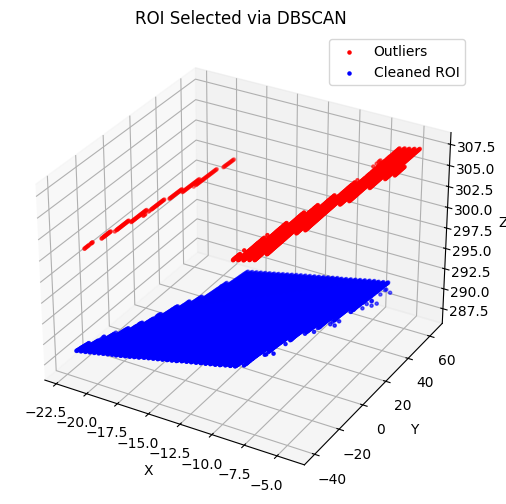

In [19]:
def remove_outliers_plane_fit(points, distance_thresh=2.0, vis=False):
    # Use function to determine the plane majority of points lie on (in case large noise)
    clustering = DBSCAN(eps=2.0, min_samples=10).fit(points)
    labels = clustering.labels_
    largest_cluster = np.argmax(np.bincount(labels[labels != -1]))
    majority_points = points[labels == largest_cluster]
    # Fit plane using majority points from clustering
    pca = PCA(n_components=3)
    pca.fit(majority_points)
    # Normal of best-fit plane
    normal_vector = pca.components_[-1]
    centroid = np.mean(majority_points, axis=0)

    plane_size = 1.2 * np.max(np.linalg.norm(points - centroid, axis=1))
    v1 = pca.components_[0]
    v2 = pca.components_[1]
    if vis:
        grid_x = np.linspace(-plane_size, plane_size, 10)
        grid_y = np.linspace(-plane_size, plane_size, 10)
        grid_x, grid_y = np.meshgrid(grid_x, grid_y)
        plane_points = centroid + grid_x[..., None] * v1 + grid_y[..., None] * v2
        plane_x, plane_y, plane_z = plane_points[..., 0], plane_points[..., 1], plane_points[..., 2]
        fig = go.Figure()
        # Add 3D scatter points
        fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers',
                                   marker=dict(size=3, color='blue'), name='Points'))
        # Plot plane
        fig.add_trace(go.Surface(x=plane_x, y=plane_y, z=plane_z, opacity=0.5, colorscale='Viridis',
                                 name='Best-fit Plane', showscale=False))
        fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
                          title='Best-Fit Plane and Points')
        fig.show()

    # Compute distance of each point to the plane
    diffs = points - centroid
    distances = np.dot(diffs, normal_vector)
    mask = np.abs(distances) < distance_thresh
    return points[mask], mask, distances

step_data_last = data[0]
new_coords = step_data_last[:, 5:8] + step_data_last[:, 8:11]

_, is_inlier_global, _ = remove_outliers_plane_fit(new_coords, distance_thresh=2.0, vis=False)

# Filter the original coordinates to get the cleaned Region of Interest (ROI)
roi_coords = new_coords[is_inlier_global]
outliers = new_coords[~is_inlier_global]


# --- Visualize the results ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot outliers in red
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2], s=5, c='red', label='Outliers')
# Plot the main cluster (ROI) in blue
ax.scatter(roi_coords[:, 0], roi_coords[:, 1], roi_coords[:, 2], s=5, c='blue', label='Cleaned ROI')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('ROI Selected via DBSCAN')
ax.legend()
plt.show()

# Visualize Data Points


Rotation Matrix R:
[[ 0.95057065  0.00455926  0.31047489]
 [ 0.00455926  0.99957946 -0.02863756]
 [-0.31047489  0.02863756  0.95015011]]


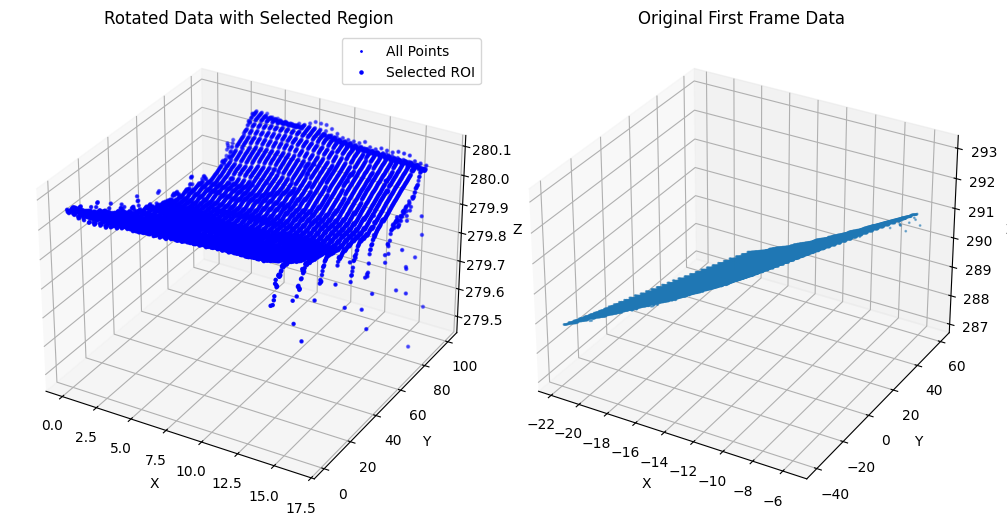

In [20]:
def get_rotation_from_plane(points):
    """
    Calculates a rotation matrix to align a plane-fitted point cloud with the XY plane.

    Args:
        points (np.ndarray): An (N, 3) array of 3D points.

    Returns:
        np.ndarray: A (3, 3) rotation matrix.
    """
    # 1. Fit a plane using PCA to find the normal vector
    pca = PCA(n_components=3)
    pca.fit(points)
    # The normal vector is the component with the smallest variance (the 3rd one)
    normal_vector = pca.components_[2]

    # 2. Ensure consistent normal vector orientation (same as MATLAB code)
    if normal_vector[0] > 0:
        normal_vector = -normal_vector

    # 3. Define the target normal (Z-axis for the XY plane)
    target_normal = np.array([0, 0, 1])

    # 4. Compute rotation axis and angle
    rotation_axis = np.cross(normal_vector, target_normal)
    rotation_axis /= np.linalg.norm(rotation_axis)

    cos_theta = np.dot(normal_vector, target_normal)
    theta = np.arccos(cos_theta)

    # 5. Create rotation matrix using Rodrigues' formula
    K = np.array([[0, -rotation_axis[2], rotation_axis[1]],
                  [rotation_axis[2], 0, -rotation_axis[0]],
                  [-rotation_axis[1], rotation_axis[0], 0]])

    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)

    return R

# --- Main Execution ---
# 2. Get the points for plane fitting and rotation
points_to_rotate = roi_coords

# 3. Calculate the rotation matrix and apply it
R = get_rotation_from_plane(points_to_rotate)
# Use the @ operator for matrix multiplication
rotated_points = (R @ points_to_rotate.T).T

rotated_points[:,0]= rotated_points[:,0] -np.min(rotated_points[:,0])
rotated_points[:,1]= rotated_points[:,1] -np.min(rotated_points[:,1])

print("\nRotation Matrix R:")
print(R)
# 4. Select a region of interest from the ROTATED data
# These values define a bounding box; you may need to adjust them.

roi_points = rotated_points

# 5. Visualize the results
fig = plt.figure(figsize=(10, 6))

# Plot 1: Original Data
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(points_to_rotate[:,0], points_to_rotate[:,1], points_to_rotate[:,2], s=1, alpha=0.5)
ax1.set_title("Original First Frame Data")
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Plot 2: Rotated Data with ROI
ax2 = fig.add_subplot(1, 2, 1, projection='3d')
# Plot all rotated points in grey
ax2.scatter(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], s=1, c='blue', label='All Points')
# Plot the selected ROI points in blue
ax2.scatter(roi_points[:,0], roi_points[:,1], roi_points[:,2], s=5, c='blue', label='Selected ROI')
ax2.set_title("Rotated Data with Selected Region")
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend()

plt.tight_layout()
plt.show()

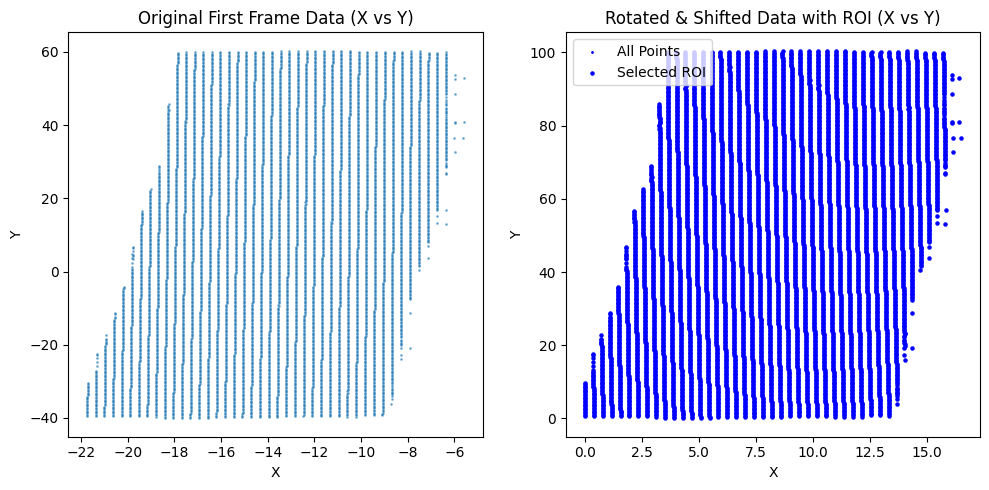

In [21]:
# Visualize the results in 2D
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Original Data (X vs Y)
axs[0].scatter(points_to_rotate[:, 0], points_to_rotate[:, 1], s=1, alpha=0.5)
axs[0].set_title("Original First Frame Data (X vs Y)")
axs[0].set_xlabel('X'); axs[0].set_ylabel('Y')
# axs[0].set_aspect('equal', adjustabl  e='box')

# Plot 2: Rotated & Shifted Data with ROI (X vs Y)
axs[1].scatter(rotated_points[:, 0], rotated_points[:, 1], s=1, c='blue', label='All Points')
axs[1].scatter(roi_points[:, 0], roi_points[:, 1], s=5, c='blue', label='Selected ROI')
axs[1].set_title("Rotated & Shifted Data with ROI (X vs Y)")
axs[1].set_xlabel('X'); axs[1].set_ylabel('Y')
axs[1].legend()
# axs[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Data Selection

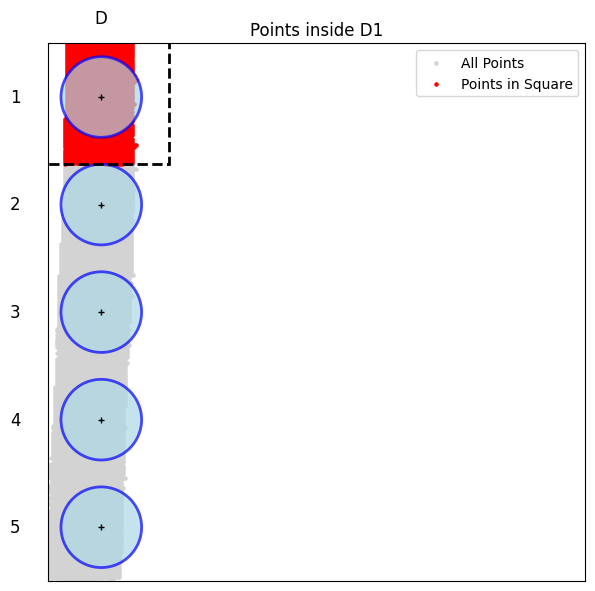

Found 1977 points inside the square.


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dimple_diameter = 15  # mm
dimple_radius = dimple_diameter / 2
spacing = 20  # mm
square_side = spacing/2 + 2 * dimple_radius  # 35 mm
half_side = square_side / 2

# Positions and labels
positions = np.arange(0, 100, spacing) + 10
X, Y = np.meshgrid(positions[0], positions)
centers = np.vstack([X.ravel(), Y.ravel()]).T

# select_dimple = 'C3`'  # Define the target dimple
# Define the target cell directly
cell_to_highlight =select_dimples[0] # 'C3'

transformed_points = rotated_points

# Automatically find coordinates for the target cell
col_char = cell_to_highlight[0]
row_char = cell_to_highlight[1:]
col_idx = col_labels.index(col_char)
row_label_idx = row_labels.index(row_char)
row_pos_idx = len(row_labels) - 1 - row_label_idx
x_center = positions[col_idx]
y_center = positions[row_pos_idx]

# Compute bottom-left corner of the square and draw it
square_x = x_center - half_side
square_y = y_center - half_side
square = plt.Rectangle((square_x, square_y), square_side, square_side,
                       edgecolor='black', facecolor='none', lw=2, linestyle='--')
ax.add_patch(square)


mask = (
    (transformed_points[:, 0] >= square_x) &
    (transformed_points[:, 0] <= square_x + square_side) &
    (transformed_points[:, 1] >= square_y) &
    (transformed_points[:, 1] <= square_y + square_side)
)

# Apply the mask to get the points for further processing
points_inside_square = transformed_points[mask]

# --- 4. Plotting and Visualization ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

# Plot all points in a light color
ax.scatter(transformed_points[:, 0], transformed_points[:, 1], s=5, c='lightgray', label='All Points')
# Plot the selected points in a prominent color
ax.scatter(points_inside_square[:, 0], points_inside_square[:, 1], s=5, c='red', label='Points in Square')

# Draw circles and their centers
for i, (x, y) in enumerate(centers):
    circle = plt.Circle((x, y), dimple_radius, edgecolor='blue', facecolor='lightblue', lw=2, alpha=0.7)
    ax.add_patch(circle)
    ax.plot(x, y, 'k+', markersize=5)

# Draw the selection square
square = plt.Rectangle((square_x, square_y), square_side, square_side,
                       edgecolor='black', facecolor='none', lw=2, linestyle='--')
ax.add_patch(square)

# Add labels
ax.text(positions[0], 100 + 3, col_labels[0], ha='center', va='bottom', fontsize=12)
for i in range(5):
    ax.text(-5, positions[4 - i], row_labels[i], ha='right', va='center', fontsize=12)

# Final settings
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Points inside {cell_to_highlight}")
plt.grid(True, linestyle='--', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# You can now use 'points_inside_square' for further processing
print(f"Found {len(points_inside_square)} points inside the square.")

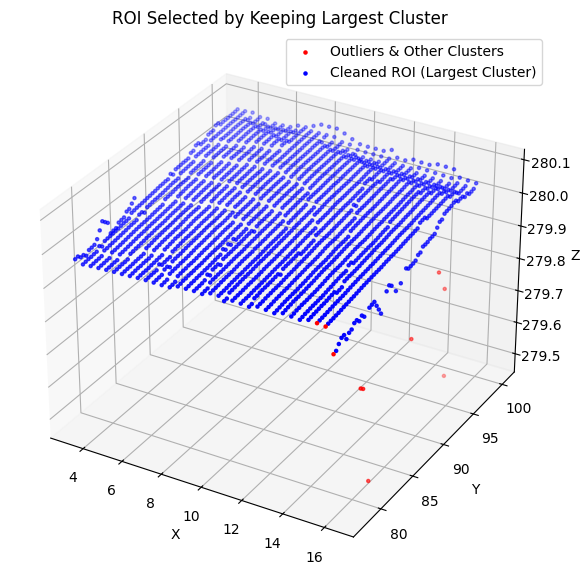

In [23]:
# --- Implement DBSCAN to find the main cluster ---
# Note: You may need to tune 'eps' and 'min_samples' for your specific data.
# 'eps' is the max distance between points to be considered neighbors.
# 'min_samples' is the number of neighbors a point needs to be a core point.
points_inside_square = rotated_points[mask]
new_coords =points_inside_square
# --- 1. Find optimal eps and run DBSCAN  ---
min_samples = 10
k = min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(new_coords)
distances, _ = nbrs.kneighbors(new_coords)
k_distances = np.sort(distances[:, k-1])
knee = KneeLocator(range(1, len(k_distances)+1), k_distances, S=10.0, curve="convex", direction="increasing")
optimal_eps = knee.elbow_y if knee.elbow_y else 1.0 # Fallback eps

db = DBSCAN(eps=optimal_eps, min_samples=min_samples).fit(new_coords)
labels = db.labels_


# --- 2. Post-Process DBSCAN Results to Find the Largest Cluster ---
# Find all unique cluster labels. The label -1 is for noise.
# --- 2. Post-Process DBSCAN Results to Find the Largest Cluster ---
# Get the labels from the DBSCAN result
labels = db.labels_

# Find all unique cluster labels. The label -1 is for noise.
unique_labels_set = set(labels)
if -1 in unique_labels_set:
    unique_labels_set.remove(-1)

# Convert the set of labels to a list to allow indexing
unique_labels = list(unique_labels_set)

# Find the label of the largest cluster
if len(unique_labels) > 0:
    # Count points in each cluster by iterating through the list
    cluster_sizes = [np.sum(labels == label) for label in unique_labels]

    # Find the list index of the largest cluster
    largest_cluster_idx = np.argmax(cluster_sizes)

    # Get the corresponding label from the list using the index
    largest_cluster_label = unique_labels[largest_cluster_idx]

    # Create a final mask to select only the largest cluster
    is_in_largest_cluster = (labels == largest_cluster_label)
else:
    # Handle case where no clusters were found
    is_in_largest_cluster = np.zeros_like(labels, dtype=bool)

# The final ROI is the largest cluster. Everything else is an outlier.
final_roi_coords = new_coords[is_in_largest_cluster]
outliers = new_coords[~is_in_largest_cluster]


# --- 3. Visualize the final results ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
# Plot outliers (includes noise AND smaller clusters)
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2], s=5, c='red', label='Outliers & Other Clusters')
# Plot the main cluster (ROI)
ax.scatter(final_roi_coords[:, 0], final_roi_coords[:, 1], final_roi_coords[:, 2], s=5, c='blue', label='Cleaned ROI (Largest Cluster)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('ROI Selected by Keeping Largest Cluster')
ax.legend()
plt.show()

idx0 = np.where(is_inlier_global)[0]              # indices of True in mask
idx1 = np.where(mask)[0]             # indices of True in mask1 (applied to data[mask])
idx2 = np.where(is_in_largest_cluster)[0]            # indices of True in mask2 (applied to data[mask][mask1])

# Step 2: map back to original data indices
ind = idx0[idx1[idx2]]


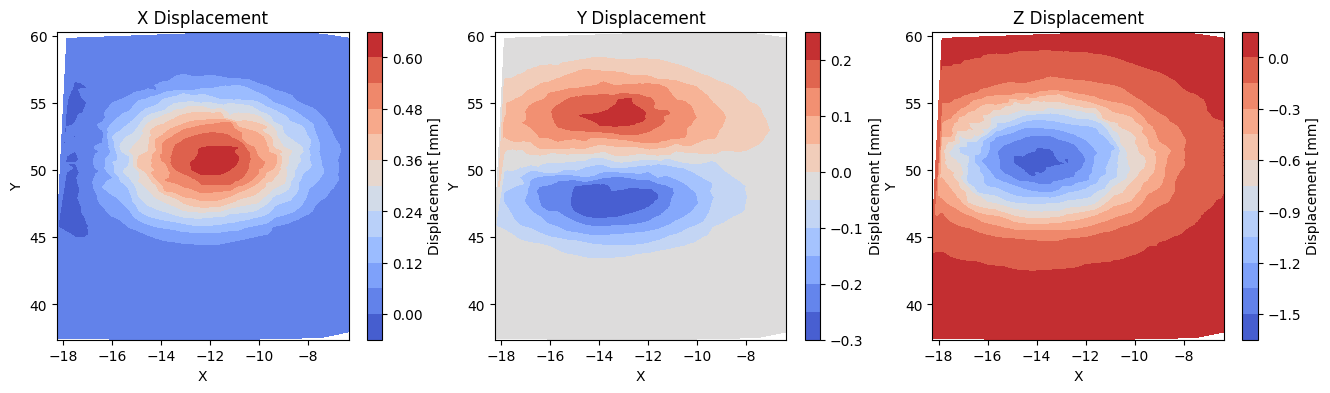

In [24]:
stepData = data[-1]
X0 = stepData[ind, 5:8]
U_frame = stepData[ind, 8:11] - data[0][ind, 8:11]


plot_vals = np.column_stack((X0[:,0], X0[:,1], U_frame[:, 0]))
triang_q = tri.Triangulation(plot_vals[:, 0], plot_vals[:, 1])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
contour_plot = axes[0].tricontourf(triang_q, plot_vals[:, 2], levels=10, cmap="coolwarm")
fig.colorbar(contour_plot, ax=axes[0], label='Displacement [mm]')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('X Displacement')
contour_plot2 = axes[1].tricontourf(triang_q, U_frame[:, 1], levels=10, cmap="coolwarm")
fig.colorbar(contour_plot2, ax=axes[1], label='Displacement [mm]')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('Y Displacement')

contour_plot3 = axes[2].tricontourf(triang_q, U_frame[:, 2], levels=10, cmap="coolwarm")
fig.colorbar(contour_plot3, ax=axes[2], label='Displacement [mm]')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].set_title('Z Displacement')
plt.show()

# Rigid body removal

776


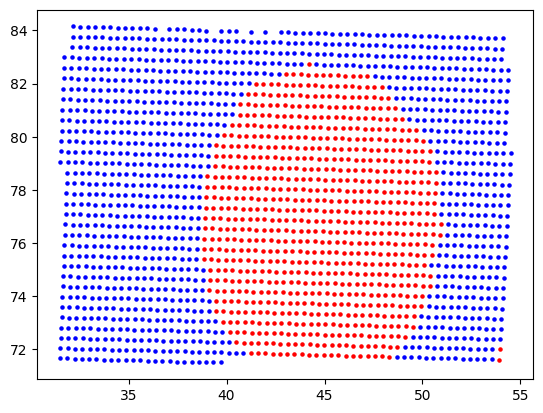

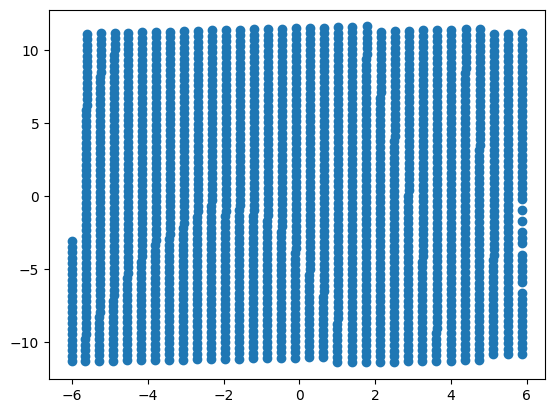

In [25]:
# Initialize lists to store the processed data for each frame
X_def_all, X_corr_all, X_rot_all, X0_all = [[[] for j in range(len(select_dimples))] for i in range(4)]
all_base = []

num_frames = np.shape(data)[0]
'''ind = final_inds[0]
X0 = data[0][ind, :3]'''
# --- Main processing loop for each frame ---
for i in range(num_frames):
    stepData = data[i]
    for j in range(len(select_dimples)):
      # Get initial coordinates (MODEL_COORDINATES) and displacements for the ROI

      # 1. Calculate deformed coordinates
      X0 = stepData[ind, 5:8]
      U_frame = stepData[ind, 8:11]
      X_def = X0 + U_frame

      # 2. Kabsch Algorithm to remove rigid body motion
      X0_mean = np.mean(X0, axis=0)
      X_def_mean = np.mean(X_def, axis=0)
      H = (X0 - X0_mean).T @ (X_def - X_def_mean)
      U_k, s, Vt_k = np.linalg.svd(H)
      R_kabsch = Vt_k.T @ U_k.T

      # Ensure a proper rotation matrix (determinant > 0)
      if np.linalg.det(R_kabsch) < 0:
        Vt_k[2, :] *= -1
        R_kabsch = Vt_k.T @ U_k.T

      t = X_def_mean - (R_kabsch @ X0_mean)

      X_rigid = (R_kabsch @ X0.T).T + t
      U_rigid_removed = X_def - X_rigid

      # 3. First PCA to establish a local coordinate system
      pca1 = PCA(n_components=3)
      X0_centered = X0 - np.mean(X0, axis=0)
      pca1.fit(X0_centered)
      R_global_to_local = pca1.components_

      U_local = (R_global_to_local @ U_rigid_removed.T).T
      U_total = (R_global_to_local @ X_def.T).T
      X_local_initial = (R_global_to_local @ X0.T).T

      # 4. Second PCA for fine-tuning alignment (based on a "base" region)
      xu = np.column_stack([X_local_initial[:, 0], X_local_initial[:, 1], U_local[:, 2]])
      xu_total = np.column_stack([X_local_initial[:, 0], X_local_initial[:, 1], U_total[:, 2]])

      # Select base indices using the same logic
      # Fit a plane model using our custom class
      # 'residual_threshold' is the max distance a point can be from the plane to be an inlier.
      model_robust, is_base_mask = ransac(xu, PlaneModel, min_samples=3,
                                      residual_threshold=0.1, max_trials=100)

      # Separate the points using the mask returned by RANSAC

      base_points = xu[is_base_mask]
      deformed_points = xu[~is_base_mask]
      base_indices =is_base_mask
      # # Note: X0 uses original global coordinates
      # base_indices = X0[:, 0] > 15

      # Avoid errors if no points match the criteria
      if np.any(base_indices):
        xu_base_mean = np.mean(xu[base_indices], axis=0)
        pca2 = PCA(n_components=3)
        xu_centered_base = xu[base_indices] - xu_base_mean
        pca2.fit(xu_centered_base)
        R_to_local = pca2.components_

        # Apply this refined rotation to all points
        U_centered = U_local - np.mean(U_local[base_indices], axis=0)
        # Ut_centered = U_total - np.mean(U_total[base_indices], axis=0)
        X_centered2 = xu - xu_base_mean

        X_corr = (R_to_local @ X_centered2.T).T
        U_local_final = (R_to_local @ U_centered.T).T # Not used in plot
        U_total_final = (R_to_local @ U_total.T).T # Not used in plot
      else: # Fallback if no base points are found
        X_corr = xu

      # Store results for plotting
      X_def_all[j].append(X_def)
      X_rot_all[j].append(U_total)
      X_corr_all[j].append(X_corr)
      X0_all[j].append(X0) # Storing for color data

      if i == num_frames - 1:
        all_base.append(is_base_mask)
        print(sum(~is_base_mask))
        plt.scatter(base_points[:,0], base_points[:,1], s=5, c='blue', label='Base')
        plt.scatter(deformed_points[:,0], deformed_points[:,1], s=5, c='red', label='Deformed')
        plt.show()

plt.scatter(X0_centered[:, 0], X0_centered[:, 1])
plt.show()

for i in range(len(select_dimples)):
  X_def_dim = np.array(X_def_all[i])
  X_corr_dim = np.array(X_corr_all[i])
  X_corr_dim[:, :, -1] = X_corr_dim[:, :, -1] - X_corr_dim[0, :, -1]
  X0_dim = np.array(X0_all[i])
  X_rot_dim = np.array(X_rot_all[i])
  np.save("%s/X_def_dim%s.npy" % (save_path, select_dimples[i]), np.array(X_def_dim))
  np.save("%s/X_corr_dim%s.npy" % (save_path, select_dimples[i]), np.array(X_corr_dim))
  np.save("%s/X_rot_dim%s.npy" % (save_path, select_dimples[i]), np.array(X_corr_dim))
  np.save("%s/X0_dim%s.npy" % (save_path, select_dimples[i]), np.array(X0_dim))

DIMPLE D1
Fitted Center (Peak): (1.98, -1.36)
Max height (Peak): 1.6069040362723217


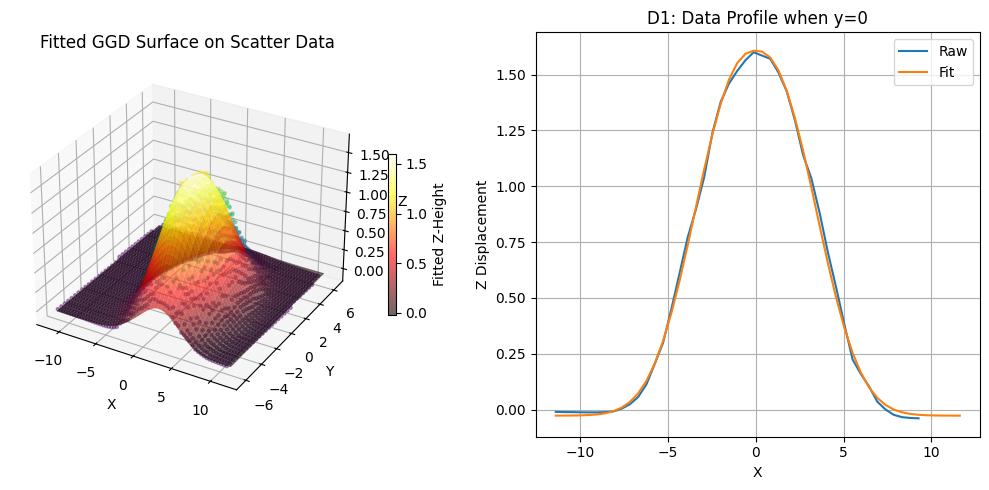

In [26]:
from scipy.optimize import curve_fit

def rot_gauss(xy, A, x0, y0, sx, sy, theta, p, offset):
    xv, yv = xy
    ct, st = np.cos(theta), np.sin(theta)
    xp = ct*(xv-x0) + st*(yv-y0)
    yp = -st*(xv-x0) + ct*(yv-y0)
    core = (np.abs(xp/sx)**p + np.abs(yp/sy)**p)
    return offset + A * np.exp(-0.5 * core)

fit_params_final, all_plot_vals = [[] for i in range(2)]
for i in range(len(select_dimples)):
  GDD_plot = True
  print(f"DIMPLE {select_dimples[i]}")
  X_corr_dim = np.load("%s/X_corr_dim%s.npy" % (save_path, select_dimples[i]))
  # --- 1. Prepare Data for Direct Fitting ---
  frame = -1
  corrected_points = X_corr_dim[0]
  corrected_points_final = X_corr_dim[-1]
  x_data = corrected_points[:, 0]
  y_data = corrected_points[:, 1]
  z_data = -corrected_points_final[:, 2]
  all_plot_vals.append(np.column_stack((x_data, y_data, z_data)))

  # z_data = np.abs(corrected_points[:, 2])

  # --- 3. Fit the Model Directly to the Scatter Data ---
  # Combine x and y data for curve_fit
  xy_data_for_fit = np.vstack((x_data, y_data))
  sx0 = sy0 = max(np.ptp(x_data), np.ptp(y_data)) / 4.0

  # Define initial guesses and bounds based on the raw data
  p0 = [np.max(z_data), 0, 0, sx0, sy0, 0.0, 2, np.min(z_data)]
  lower = [0, -5, -5, 1e-3, 1e-3, -np.pi/2, 2, -np.inf]
  upper = [np.max(z_data) * 1.5, 5, 5, np.ptp(x_data)*2, np.ptp(y_data)*2, np.pi/2, 3, np.inf]
  # Perform the curve fitting
  try:
    params_fit, _ = curve_fit(rot_gauss, xy_data_for_fit, z_data,
                              p0=p0, bounds=(lower, upper))
    fit_params_final.append(params_fit)

    z_fit = rot_gauss(xy_data_for_fit, *params_fit)
    surface_centroid = params_fit[1:3]

    print(f"Fitted Center (Peak): ({surface_centroid[0]:.2f}, {surface_centroid[1]:.2f})")
    print(f"Max height (Peak): {np.max(z_fit)}")
    points_recentered = corrected_points - [surface_centroid[0], surface_centroid[1], 0]
  except RuntimeError:
    print("GDD surface fit failed")
    points_recentered = corrected_points - np.mean(corrected_points, axis=0)
    GDD_plot = False

  fig = plt.figure(figsize=(10, 5))
  ax1 = fig.add_subplot(1, 2, 1, projection='3d')
  ax2 = fig.add_subplot(1, 2, 2)
  ax1.scatter(x_data, y_data, z_data, s=5, c=z_data, cmap='viridis', alpha=0.4, label='Original Points')
  x_grid_range = np.linspace(x_data.min(), x_data.max(), 50)
  y_grid_range = np.linspace(y_data.min(), y_data.max(), 50)
  y0_points = np.column_stack((x_grid_range, np.zeros(x_grid_range.shape)))
  raw_y0 = griddata(points_recentered[:, 0:2], z_data, y0_points, method='linear')
  ax2.plot(y0_points[:, 0], raw_y0, label="Raw")


  if GDD_plot:
    X_grid, Y_grid = np.meshgrid(x_grid_range, y_grid_range)
    Z_fit = rot_gauss(np.vstack((X_grid.ravel(), Y_grid.ravel())), *params_fit).reshape(50, 50)
    # Plot the fitted GGD surface and capture its mappable object
    surf_plot = ax1.plot_surface(X_grid, Y_grid, Z_fit, cmap='hot', edgecolor='none', alpha=0.6)
    fig.colorbar(surf_plot, ax=ax1, shrink=0.4, label='Fitted Z-Height')
    # Plot 2: The recentered scatter data
    params_fit_c = np.copy(params_fit)
    params_fit_c[1:3] = 0
    fit_y0 = rot_gauss(np.vstack((y0_points[:,0], y0_points[:,1])), *params_fit_c)
    # fit_y0 = griddata(np.column_stack((X_grid.flatten(), Y_grid.flatten())), Z_fit_mod.flatten(), y0_points, method='linear')
    ax2.plot(y0_points[:, 0], fit_y0, label="Fit")
  ax1.set_title("Fitted GGD Surface on Scatter Data")
  ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
  ax2.set_title("%s: Data Profile when y=0" % select_dimples[i])
  ax2.set_xlabel('X'); ax2.set_ylabel('Z Displacement')
  ax2.grid(True)
  ax2.legend()
  plt.tight_layout()
  plt.show()

DIMPLE D1
[ 1.98479732 -1.36300393]


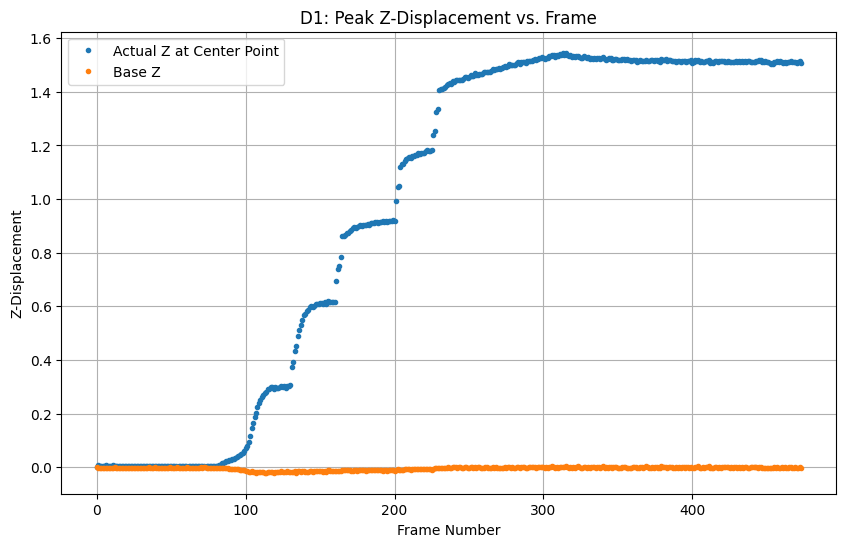

In [27]:
actual_peak_displacements, mean_displacements = [[[] for j in range(len(select_dimples))] for i in range(2)]
dist_all = []
for i, select_dimple in enumerate(select_dimples):
  os.makedirs("%s/%s/GGDrot_fit" % (save_path, select_dimple), exist_ok=True)
  print(f"DIMPLE {select_dimples[i]}")
  X_corr_dim = np.load("%s/X_corr_dim%s.npy" % (save_path, select_dimple))
  num_frames = X_corr_dim.shape[0]
  corrected_points = X_corr_dim[-1]
  x_data = corrected_points[:, 0]
  y_data = corrected_points[:, 1]
  params = fit_params_final[i]
  cent = params[1:3]
  print(cent)
  dist = np.abs(x_data - cent[0]) + np.abs(y_data - cent[1])
  dist_all.append(dist)
  for j in range(num_frames):
    corrected_points = X_corr_dim[j]
    z_data = -corrected_points[:, 2]
    actual_peak_z = z_data[np.argmin(dist)]
    actual_peak_displacements[i].append(actual_peak_z)
    base_inds = all_base[i]
    mean_displacements[i].append(np.mean(z_data[base_inds]))
    # mean_displacements[i].append(np.mean(z_data))
  np.save("%s/%s/%s_actual_peak_displacements.npy" % (save_path, select_dimple, select_dimple), np.array(actual_peak_displacements[i]))
  np.save("%s/%s/%s_mean_displacements.npy" % (save_path, select_dimple, select_dimple), np.array(mean_displacements[i]))

  plt.figure(figsize=(10, 6))
  plt.plot(range(num_frames), actual_peak_displacements[i], 'o', label='Actual Z at Center Point', markersize=3)
  # plt.plot(range(num_frames), mean_displacements[i], 'o', label='Mean Z', markersize=3)
  plt.plot(range(num_frames), mean_displacements[i], 'o', label='Base Z', markersize=3)
  plt.title(f'{select_dimples[i]}: Peak Z-Displacement vs. Frame')
  plt.xlabel('Frame Number')
  plt.ylabel('Z-Displacement')
  plt.legend()
  plt.grid(True)
  plt.savefig("%s/%s/%s_Z_displacement_comp.png" % (save_path, select_dimple, select_dimple))
  plt.show()

# Gaussian Fit

DIMPLE D1
Fitted Center (Peak): (2.00, -1.37)
Max height (Peak): 0.6591349334842265


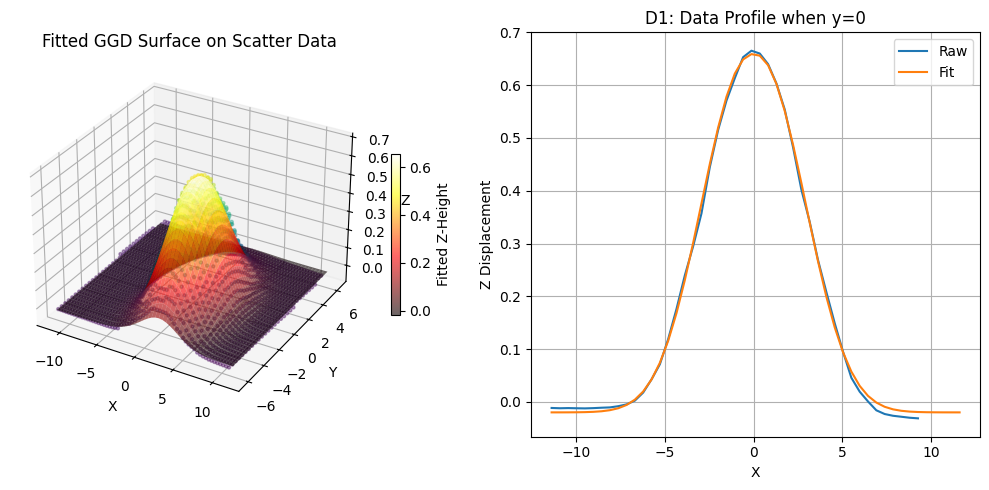

In [28]:
def rot_gauss(xy, A, x0, y0, sx, sy, theta, p, offset):
    xv, yv = xy
    ct, st = np.cos(theta), np.sin(theta)
    xp = ct*(xv-x0) + st*(yv-y0)
    yp = -st*(xv-x0) + ct*(yv-y0)
    core = (np.abs(xp/sx)**p + np.abs(yp/sy)**p)
    return offset + A * np.exp(-0.5 * core)

fit_params_final, all_plot_vals = [[] for i in range(2)]
for i in range(len(select_dimples)):
  GDD_plot = True
  print(f"DIMPLE {select_dimples[i]}")
  X_corr_dim = np.load("%s/X_corr_dim%s.npy" % (save_path, select_dimples[i]))
  # --- 1. Prepare Data for Direct Fitting ---
  frame = -1
  corrected_points = X_corr_dim[0]
  corrected_points_final = X_corr_dim[144]
  x_data = corrected_points[:, 0]
  y_data = corrected_points[:, 1]
  z_data = -corrected_points_final[:, 2]
  all_plot_vals.append(np.column_stack((x_data, y_data, z_data)))

  # z_data = np.abs(corrected_points[:, 2])

  # --- 3. Fit the Model Directly to the Scatter Data ---
  # Combine x and y data for curve_fit
  xy_data_for_fit = np.vstack((x_data, y_data))
  sx0 = sy0 = max(np.ptp(x_data), np.ptp(y_data)) / 4.0

  # Define initial guesses and bounds based on the raw data
  p0 = [np.max(z_data), 0, 0, sx0, sy0, 0.0, 2, np.min(z_data)]
  lower = [0, -5, -5, 1e-3, 1e-3, -np.pi/2, 2, -np.inf]
  upper = [np.max(z_data) * 1.5, 5, 5, np.ptp(x_data)*2, np.ptp(y_data)*2, np.pi/2, 3, np.inf]
  # Perform the curve fitting
  try:
    params_fit, _ = curve_fit(rot_gauss, xy_data_for_fit, z_data,
                              p0=p0, bounds=(lower, upper))
    fit_params_final.append(params_fit)

    z_fit = rot_gauss(xy_data_for_fit, *params_fit)
    surface_centroid = params_fit[1:3]

    print(f"Fitted Center (Peak): ({surface_centroid[0]:.2f}, {surface_centroid[1]:.2f})")
    print(f"Max height (Peak): {np.max(z_fit)}")
    points_recentered = corrected_points - [surface_centroid[0], surface_centroid[1], 0]
  except RuntimeError:
    print("GDD surface fit failed")
    points_recentered = corrected_points - np.mean(corrected_points, axis=0)
    GDD_plot = False

  fig = plt.figure(figsize=(10, 5))
  ax1 = fig.add_subplot(1, 2, 1, projection='3d')
  ax2 = fig.add_subplot(1, 2, 2)
  ax1.scatter(x_data, y_data, z_data, s=5, c=z_data, cmap='viridis', alpha=0.4, label='Original Points')
  x_grid_range = np.linspace(x_data.min(), x_data.max(), 50)
  y_grid_range = np.linspace(y_data.min(), y_data.max(), 50)
  y0_points = np.column_stack((x_grid_range, np.zeros(x_grid_range.shape)))
  raw_y0 = griddata(points_recentered[:, 0:2], z_data, y0_points, method='linear')
  ax2.plot(y0_points[:, 0], raw_y0, label="Raw")


  if GDD_plot:
    X_grid, Y_grid = np.meshgrid(x_grid_range, y_grid_range)
    Z_fit = rot_gauss(np.vstack((X_grid.ravel(), Y_grid.ravel())), *params_fit).reshape(50, 50)
    # Plot the fitted GGD surface and capture its mappable object
    surf_plot = ax1.plot_surface(X_grid, Y_grid, Z_fit, cmap='hot', edgecolor='none', alpha=0.6)
    fig.colorbar(surf_plot, ax=ax1, shrink=0.4, label='Fitted Z-Height')
    # Plot 2: The recentered scatter data
    params_fit_c = np.copy(params_fit)
    params_fit_c[1:3] = 0
    fit_y0 = rot_gauss(np.vstack((y0_points[:,0], y0_points[:,1])), *params_fit_c)
    # fit_y0 = griddata(np.column_stack((X_grid.flatten(), Y_grid.flatten())), Z_fit_mod.flatten(), y0_points, method='linear')
    ax2.plot(y0_points[:, 0], fit_y0, label="Fit")
  ax1.set_title("Fitted GGD Surface on Scatter Data")
  ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
  ax2.set_title("%s: Data Profile when y=0" % select_dimples[i])
  ax2.set_xlabel('X'); ax2.set_ylabel('Z Displacement')
  ax2.grid(True)
  ax2.legend()
  plt.tight_layout()
  plt.show()

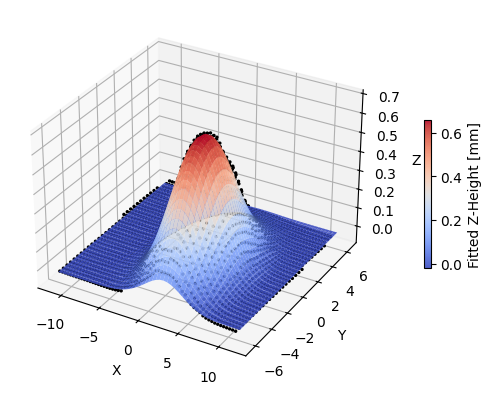

In [29]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(111, projection='3d')
x_grid_range = np.linspace(x_data.min(), x_data.max(), 50)
y_grid_range = np.linspace(y_data.min(), y_data.max(), 50)
y0_points = np.column_stack((x_grid_range, np.zeros(x_grid_range.shape)))
raw_y0 = griddata(points_recentered[:, 0:2], z_data, y0_points, method='linear')

if GDD_plot:
  X_grid, Y_grid = np.meshgrid(x_grid_range, y_grid_range)
  Z_fit = rot_gauss(np.vstack((X_grid.ravel(), Y_grid.ravel())), *params_fit).reshape(50, 50)
  # Plot the fitted GGD surface and capture its mappable object
  surf_plot = ax1.plot_surface(X_grid, Y_grid, Z_fit, cmap='coolwarm', edgecolor='none', alpha=0.9)
  fig.colorbar(surf_plot, ax=ax1, shrink=0.4, label='Fitted Z-Height [mm]')
  # Plot 2: The recentered scatter data
  params_fit_c = np.copy(params_fit)
  params_fit_c[1:3] = 0
  fit_y0 = rot_gauss(np.vstack((y0_points[:,0], y0_points[:,1])), *params_fit_c)
  # fit_y0 = griddata(np.column_stack((X_grid.flatten(), Y_grid.flatten())), Z_fit_mod.flatten(), y0_points, method='linear')
ax1.scatter(x_data, y_data, z_data, s=2, c='k', alpha=1, label='Original Points')
# ax1.set_title("Fitted GGD Surface on Scatter Data")
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
plt.tight_layout()
plt.show()

DIMPLE D1


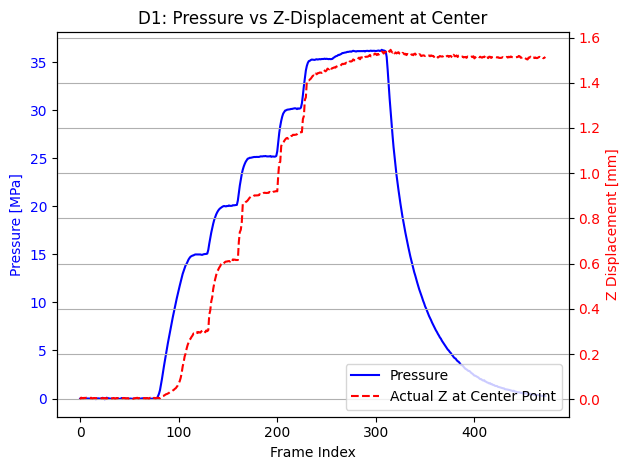

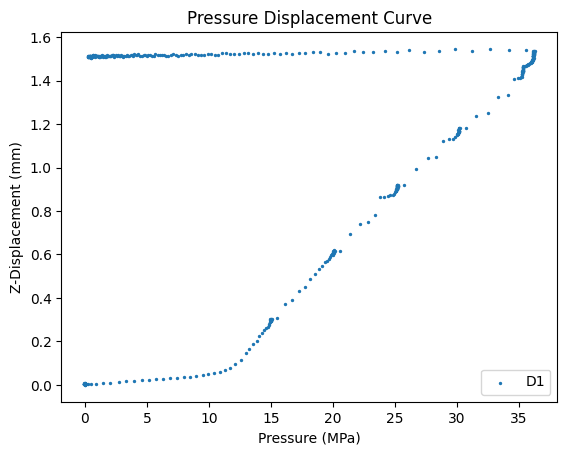

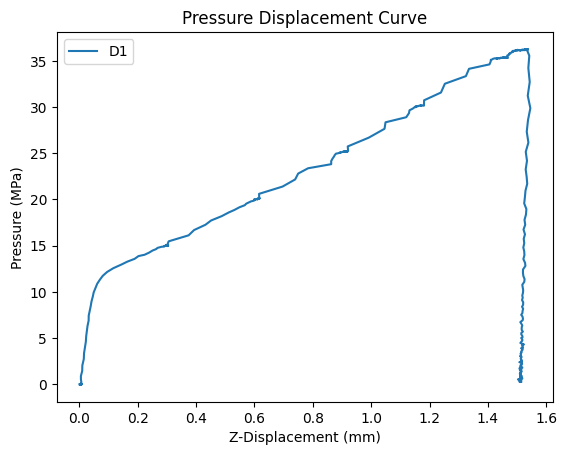

In [30]:
import pandas as pd

def same_len(p, d, t1, t2=[]):
    max_ind = np.min([len(d), len(p)])
    d = d[:max_ind]
    p = p[:max_ind]
    t1 = t1[:max_ind]
    if len(t2) != 0:
      t2 = t1[:max_ind]
    nan_inds = ~np.isnan(p)
    d = d[nan_inds]
    p = p[nan_inds]
    t1 = t1[nan_inds]
    if len(t2) != 0:
      t2 = t2[nan_inds]
      return p, d, t1, t2
    return p, d, t1

p_aligned_full, time_aligned_full, temp_aligned_full, actual_aligned_full, ggd_aligned_full = [[] for i in range(5)]
# df = pd.read_csv(aligned)

for i, select_dimple in enumerate(select_dimples):
  print(f"DIMPLE {select_dimples[i]}")
  df = pd.read_csv(glob.glob("%s/*%s_record_ALIGNED.csv" % (test_path, select_dimple))[0])
  p_aligned = np.array(df['High Acc. Transducer (PSIG)']) / 145
  temp_aligned = np.array(df['%s: Temp.(C)' % select_dimple])
  actual_peak_displacements = np.load("%s/%s/%s_actual_peak_displacements.npy" % (save_path, select_dimple, select_dimple))
  p_time = (np.array(df['time']) - np.array(df['time'])[0]) / 1e3
  p_aligned, aligned_actual, time_aligned, temp_aligned = same_len(p_aligned, actual_peak_displacements, p_time, temp_aligned)
  p_aligned_full.append(p_aligned)
  time_aligned_full.append(time_aligned)
  temp_aligned_full.append(temp_aligned)
  actual_aligned_full.append(aligned_actual)

  fig, ax1 = plt.subplots()
  ax1.plot(np.arange(len(p_aligned_full[-1])), p_aligned_full[-1], 'b-', label='Pressure')
  ax1.set_xlabel('Frame Index')  # Change label as appropriate
  ax1.set_ylabel('Pressure [MPa]', color='b')
  ax1.tick_params(axis='y', labelcolor='b')
  ax2 = ax1.twinx()
  ax2.plot(np.arange(len(p_aligned_full[-1])), actual_aligned_full[-1], 'r--', label='Actual Z at Center Point')
  ax2.set_ylabel('Z Displacement [mm]', color='r')
  ax2.tick_params(axis='y', labelcolor='r')
  lines_1, labels_1 = ax1.get_legend_handles_labels()
  lines_2, labels_2 = ax2.get_legend_handles_labels()
  plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')
  plt.title("%s: Pressure vs Z-Displacement at Center" % select_dimple)
  plt.grid(True)
  plt.tight_layout()
  plt.show()

for i, select_dimple in enumerate(select_dimples):
  if len(p_aligned_full[i]) != 0:
    plt.scatter(p_aligned_full[i], actual_aligned_full[i], s=2, label=select_dimple)
plt.xlabel("Pressure (MPa)")
plt.ylabel("Z-Displacement (mm)")
plt.title("Pressure Displacement Curve")
plt.legend()
plt.show()

for i, select_dimple in enumerate(select_dimples):
  if len(p_aligned_full[i]) != 0:
    plt.plot(actual_aligned_full[i], p_aligned_full[i], label=select_dimple)
plt.ylabel("Pressure (MPa)")
plt.xlabel("Z-Displacement (mm)")
plt.title("Pressure Displacement Curve")
plt.legend()
plt.show()

## Script: Pressure Selection
Script modified to align 1 dimple using manual alignment and apply constant lag for all dimples in test


Total number of steps: 16
[ 5.76154863  6.8811298   7.96044796  8.96175175  9.92838227 10.86673037
 12.14407243 12.96556226 14.01495139 14.89608104 14.95622224 16.11476106
 17.2568464  18.18963674 18.86211398 19.99716586]
[15]


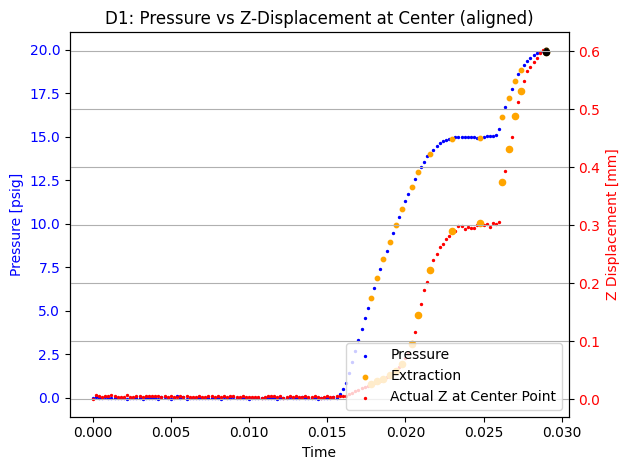

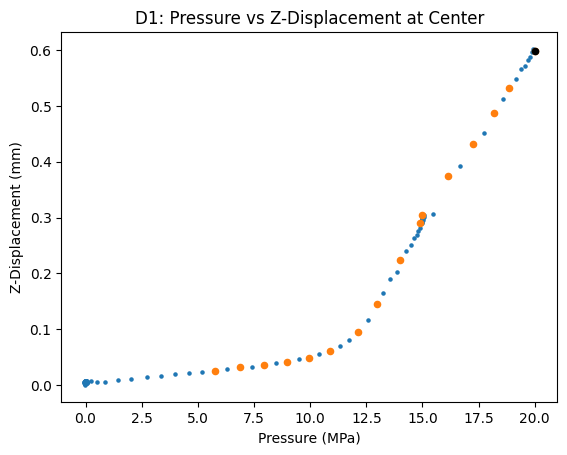

In [31]:
import numpy as np

burst = []
burst_dimples = [i[0] for i in burst]
def find_step_corners(p, win=10, min_plateau=5, min_ramp=5, ks=10.0, hys=0.9, stop_at_max=False):
    p = p[:np.argmax(p)]
    t = np.arange(0, len(p), 1)
    p = np.asarray(p)
    if stop_at_max: m = np.argmax(p); t, p = t[:m+1], p[:m+1]
    win = max(3, int(win)|1)
    ps = np.convolve(p, np.ones(win)/win, mode="same")
    dt = np.gradient(t); slope = np.gradient(ps)/np.maximum(dt, 1e-12)

    sabs = np.abs(slope)
    quiet = slope[sabs <= np.percentile(sabs, 50)]
    mad = np.median(np.abs(quiet - np.median(quiet))) if quiet.size else np.median(np.abs(slope - np.median(slope)))
    sigma = 1.4826*(mad if mad>0 else (np.std(quiet) if quiet.size else np.std(slope)))
    hi, lo = max(1e-12, ks*sigma), max(5e-13, ks*sigma*hys)

    # tiny state machine with length filters
    state = 'plateau' if np.abs(slope[0]) < lo else 'ramp'; i0 = 0
    plates, ramps = [], []
    push = lambda kind,a,b: (plates.append((a,b,ps[a:b+1].mean())) if (kind=='plateau' and b-a+1>=min_plateau)
                             else ramps.append((a,b)) if (kind=='ramp' and b-a+1>=min_ramp) else None)

    for i in range(1, len(slope)):
        s = abs(slope[i])
        if state=='plateau' and s>hi:  push('plateau', i0, i-1); i0=i-1; state='ramp'
        elif state=='ramp' and s<lo:  push('ramp', i0, i-1); i0=i-1; state='plateau'
    push(state, i0, len(slope)-1)

    corners = np.array([b for (_,b,_) in plates[:-1]] + [a for (a,_,_) in plates[1:]], int)
    return plates, corners

def reduce_ranges(arr, ind_val, threshold=0.5):
    arr = np.asarray(arr)
    result = []
    start = 0
    for i in range(1, len(arr)):
        if abs(arr[i] - arr[i-1]) > threshold:
            # close previous group
            if start == i-1:
                result.append(ind_val[start])        # single value
            else:
                result.extend([ind_val[start], ind_val[i-1]])  # range
            start = i
    # handle final group
    if start == len(arr)-1:
        result.append(ind_val[start])
    else:
        result.extend([ind_val[start], ind_val[-1]])
    return np.array(result)

def expand_data(times_arr, pressure_arr, max_timestep=2):
    # times_arr = np.concatenate([np.array([0]), times])
    # pressure_arr = np.concatenate([np.array([0]), pressure])
    new_t = [times_arr[0]]
    new_p = [pressure_arr[0]]
    indices = [0]
    for i in range(1, len(times_arr)):
        t1, p1 = times_arr[i-1], pressure_arr[i-1]
        t2, p2 = times_arr[i], pressure_arr[i]
        dt = t2 - t1
        if dt > 0: # Ensure dt is positive
            num_segments = int(np.ceil(dt / max_timestep))
            if num_segments > 1: # Only add intermediate points if more than one segment is needed
                actual_step = dt / num_segments
                for j in range(1, num_segments):
                    current_time_to_add = t1 + j * actual_step
                    new_t.append(current_time_to_add)
                    # Linearly interpolate pressure
                    interp_pressure = p1 + (current_time_to_add - t1) / dt * (p2 - p1)
                    new_p.append(interp_pressure)
        # Record the index of the current original point (times_arr[i])
        indices.append(len(new_t))
        # Add the current original point
        new_t.append(t2)
        new_p.append(p2)
    indices = np.array(indices)[1:] - 1
    return (np.array(new_t)[1:], np.array(new_p)[1:], indices)

def find_nearest_indices(array, values):
    # Find insertion points for each value in `values`.
    # `idx` will contain the index such that array[idx-1] < value <= array[idx].
    # `idx` can range from 0 to len(array).
    idx = np.searchsorted(array, values, side="left")

    # Handle edge cases:
    # For values before the first element (idx=0), the closest is the first element (array[0]).
    # For values after the last element (idx=len(array)), the closest is the last element (array[len(array)-1]).
    # For values within the array, compare array[idx] and array[idx-1].

    # Create indices for comparison, ensuring they stay within array bounds
    idx_minus_1 = np.maximum(0, idx - 1)
    idx_clamped = np.minimum(len(array) - 1, idx)

    # Compare distances to determine which of the two candidate indices is closer
    is_right_closer = np.abs(array[idx_clamped] - values) < np.abs(array[idx_minus_1] - values)

    # Select the index corresponding to the closer value
    nearest_indices = np.where(is_right_closer, idx_clamped, idx_minus_1)

    return nearest_indices

poi_all, extraction_inds = [[] for i in range(2)]
for i in range(len(select_dimples)):
  p_mod = p_aligned_full[i]
  if select_dimples[i] in burst_dimples:
    burst_index = burst_dimples.index(select_dimples[i])
    p_index = np.argmin(np.abs(p_aligned_full[i] - burst[burst_index][1]))
    p_mod = p_aligned_full[i][:p_index]

  plates, corners = find_step_corners(p_mod)
  reduced_inds = np.unique(np.clip([0, *(idx for seg in plates for idx in (seg[0], seg[1])), len(p_mod)-1], 0, len(p_mod)-1))
  reduced_p = p_mod[reduced_inds]
  pressure_drop = np.where(np.diff(reduced_p) < -2000/145)[0]
  if len(pressure_drop) != 0:
    inds_mod = list(reduced_inds[np.min(np.where(reduced_p > 500/145)[0]):(1 + pressure_drop[0])])
  else:
    inds_mod = list(reduced_inds[np.min(np.where(reduced_p > 500/145)[0]):])
  max_ind = inds_mod[-1]
  # reduced_p = p_mod[inds_mod[0]: inds_mod[-1] + 1]
  max_pressure = np.max(p_mod)
  # for val in [i/145 for i in [700, 1000, 1300, 1600, 2000, 2500]]:
  for val in list(np.arange(5, int(max_pressure), 1)):
    if np.min(np.abs(reduced_p - val)) > 0.5:
      inds_mod.append(np.argmin(np.abs(p_mod[:max_ind] - val)))
      if np.abs(val - max_pressure) < 0.5:
        break
  inds_mod = sorted(inds_mod)
  if select_dimples[i] in burst_dimples:
    inds_mod = inds_mod[:-1]
  t = (np.copy(time_aligned_full[i]) - time_aligned_full[i][0]) / 1e3
  inds_mod = reduce_ranges(p_mod[inds_mod], inds_mod)
  expanded_times, _, saved_indices = expand_data(t[inds_mod], p_mod[inds_mod], max_timestep=4)
  extraction_inds.append(saved_indices)
  inds_mod = find_nearest_indices(t, expanded_times)
  inds_mod = inds_mod[p_mod[inds_mod] < 20.]
  reduced_p = p_mod[inds_mod]
  poi_all.append(inds_mod)
  print(f"Total number of steps: {len(inds_mod)}")
  print(reduced_p)
  extraction_inds.append(list(np.where(np.diff(reduced_p) > 200)[0]) + [len(inds_mod) - 1])
  print(extraction_inds[-1])
  reduced_d = actual_aligned_full[i][inds_mod]
  reduced_t = t[inds_mod]
  reduced_time = temp_aligned_full[i][inds_mod]
  '''
  plt.scatter(t, p_aligned_full[i], s=5, c='r', label="All points")
  plt.plot(reduced_t, reduced_p, label="Reduced Points")
  plt.scatter(reduced_t, reduced_p, s=5, c='k', label="Reduced")
  plt.title("Pressure vs Time")
  plt.ylabel("Pressure")
  plt.xlabel("Time (s)")
  plt.legend()
  plt.show()
  '''
  fig, ax1 = plt.subplots()
  ax1.scatter(t[:inds_mod[-1]], p_aligned_full[i][:inds_mod[-1]], c='b', s=2, label='Pressure')
  ax1.scatter(reduced_t, reduced_p, c='orange', s=10, label="Extraction")
  ax1.scatter(reduced_t[extraction_inds[-1]], reduced_p[extraction_inds[-1]], c='k', s=10)
  ax1.set_xlabel('Time')  # Change label as appropriate
  ax1.set_ylabel('Pressure [psig]', color='b')
  ax1.tick_params(axis='y', labelcolor='b')
  ax2 = ax1.twinx()
  ax2.scatter(t[:inds_mod[-1]], actual_aligned_full[i][:inds_mod[-1]], c='r', s=2, label='Actual Z at Center Point')
  ax2.scatter(reduced_t, reduced_d, c='orange', s=20)
  ax2.scatter(reduced_t[extraction_inds[-1]], reduced_d[extraction_inds[-1]], c='k', s=20)
  ax2.set_ylabel('Z Displacement [mm]', color='r')
  ax2.tick_params(axis='y', labelcolor='r')
  lines_1, labels_1 = ax1.get_legend_handles_labels()
  lines_2, labels_2 = ax2.get_legend_handles_labels()
  plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')
  plt.title("%s: Pressure vs Z-Displacement at Center (aligned)" % select_dimples[i])
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  plt.scatter(p_aligned_full[i][:inds_mod[-1]], actual_aligned_full[i][:inds_mod[-1]], s=5, label="All Points")
  plt.scatter(reduced_p, reduced_d, s=20, label="Simulation")
  plt.scatter(reduced_p[extraction_inds[-1]], reduced_d[extraction_inds[-1]], c='k', s=20)
  plt.xlabel("Pressure (MPa)")
  plt.ylabel("Z-Displacement (mm)")
  plt.title("%s: Pressure vs Z-Displacement at Center" % select_dimples[i])
  plt.savefig("%s/%s_Mesh_fit_%s%s" % (dir_path, select_folder, select_dimples[i], ending))
  plt.show()

## Script: Results for JAX-FEM Inverse Extraction

#################     DIMPLE D1      ################# 
Centroids: X(1.6481362936488593), Y(-0.939836757576674)
sMAPE (new fit):   mean=5.25%, median=4.05%


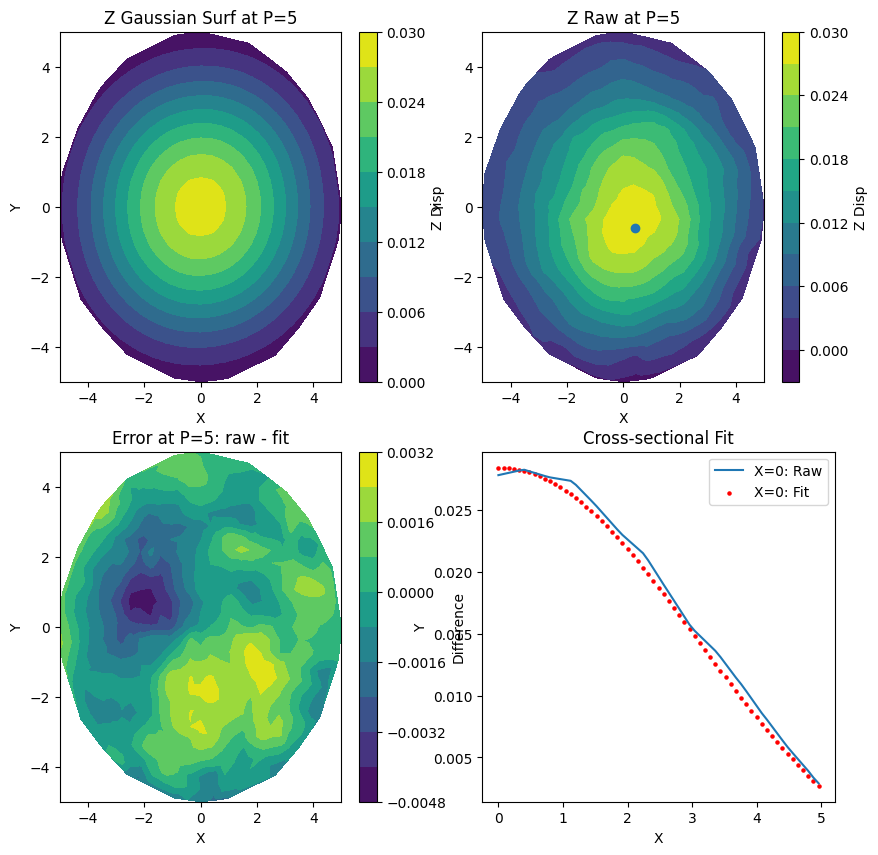

Centroids: X(1.7632530858315245), Y(-0.9058496487709701)
sMAPE (new fit):   mean=7.03%, median=1.53%


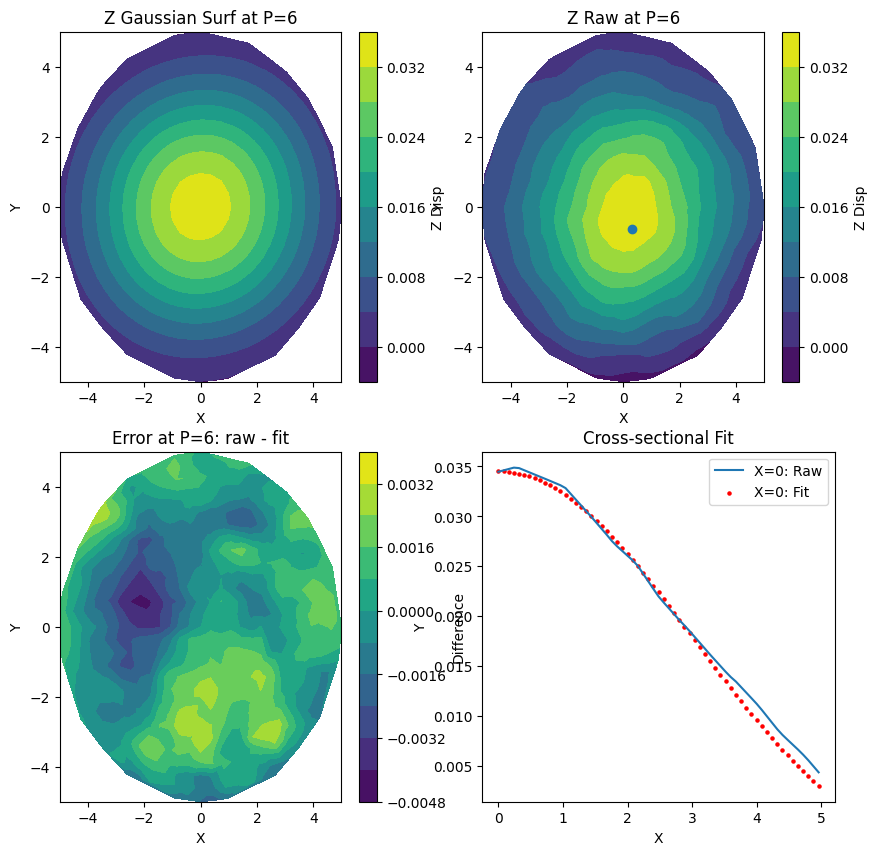

Centroids: X(1.7579201079448448), Y(-0.9932837208180745)
sMAPE (new fit):   mean=9.45%, median=2.83%


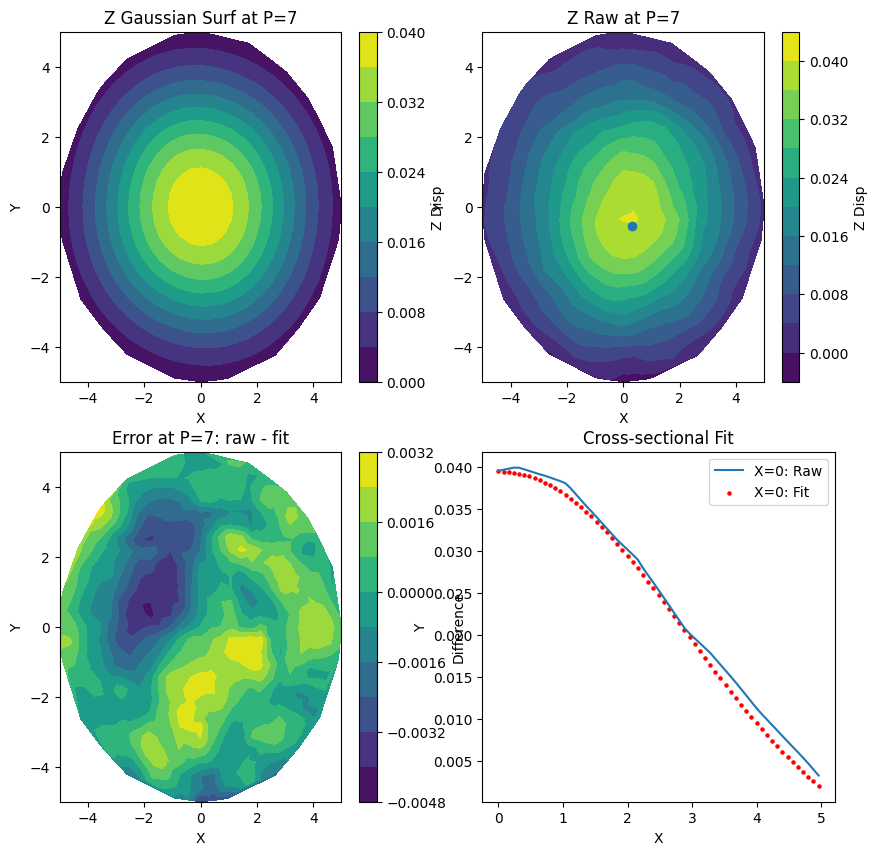

Centroids: X(1.827138156535464), Y(-1.0727682391373483)
sMAPE (new fit):   mean=6.36%, median=2.95%


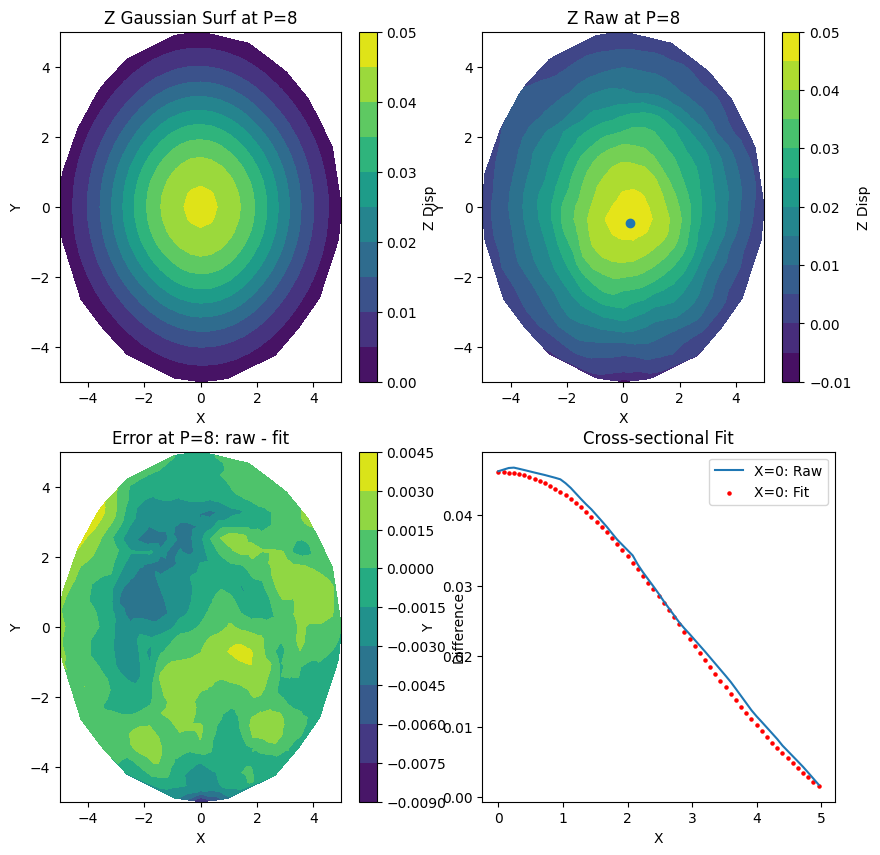

Centroids: X(1.845461500779828), Y(-1.0792004559685129)
sMAPE (new fit):   mean=11.89%, median=2.07%


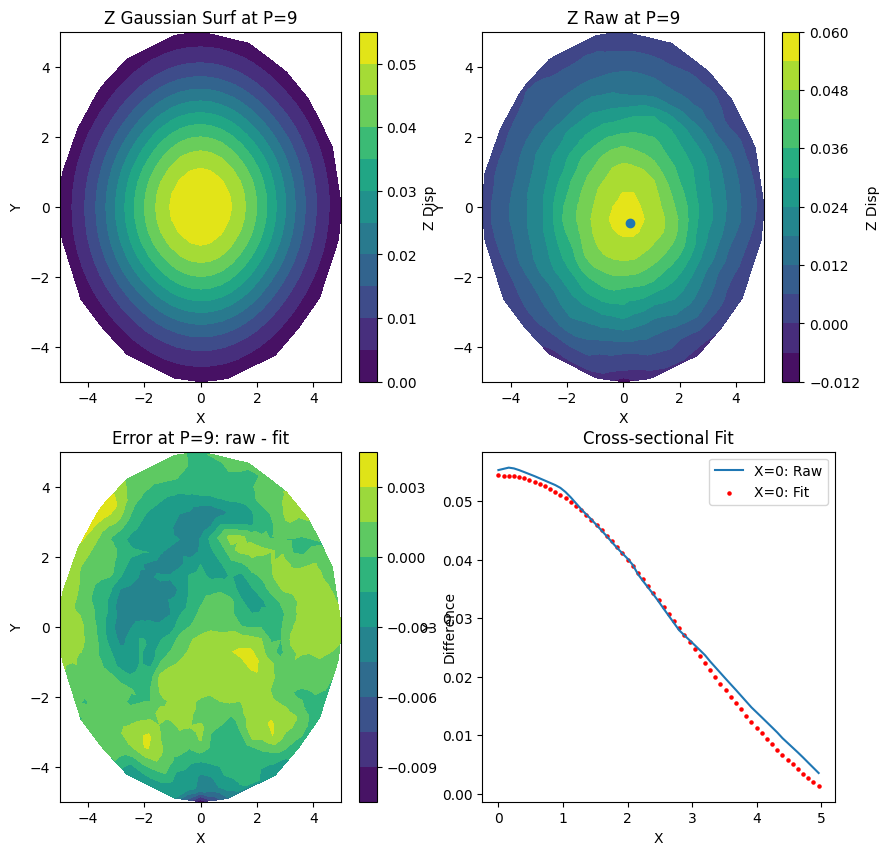

Centroids: X(1.8379074802082427), Y(-1.036696268434941)
sMAPE (new fit):   mean=6.05%, median=2.69%


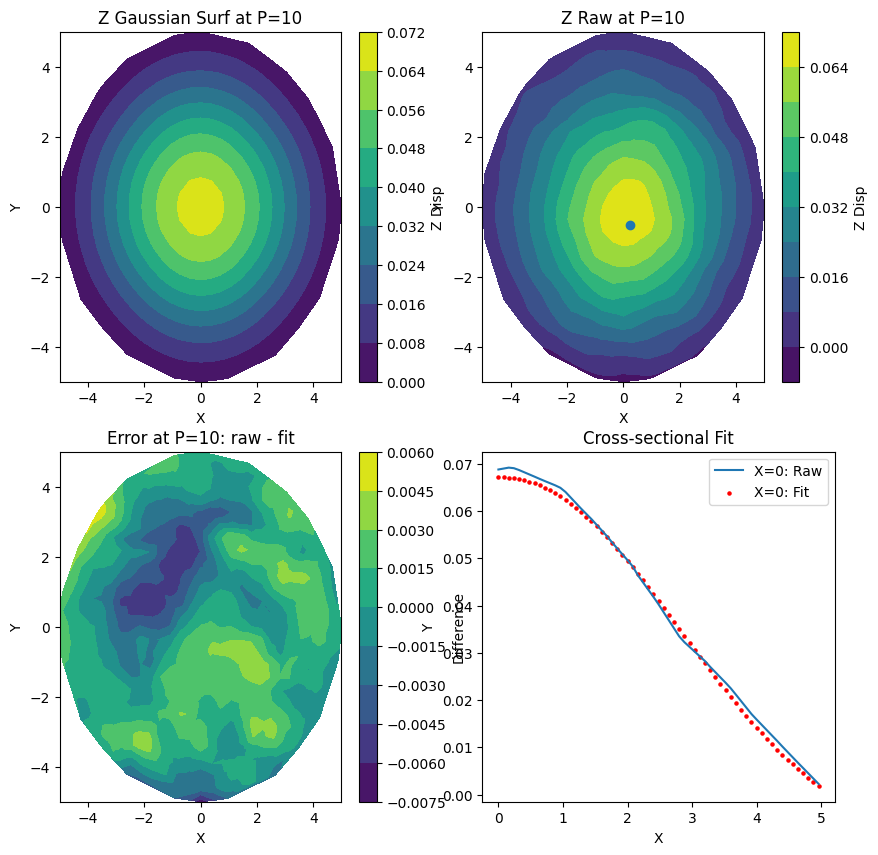

Centroids: X(1.8834783345933739), Y(-1.0718214416719898)
sMAPE (new fit):   mean=6.95%, median=2.60%


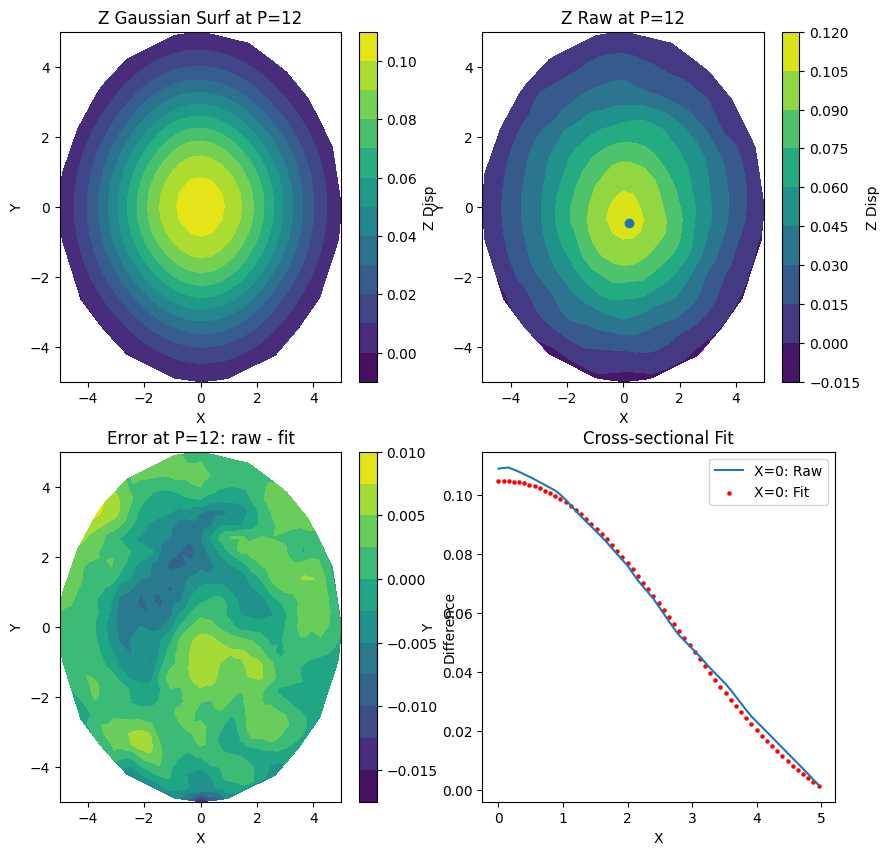

Centroids: X(2.0475153634016268), Y(-1.2972260608294715)
sMAPE (new fit):   mean=4.49%, median=2.45%


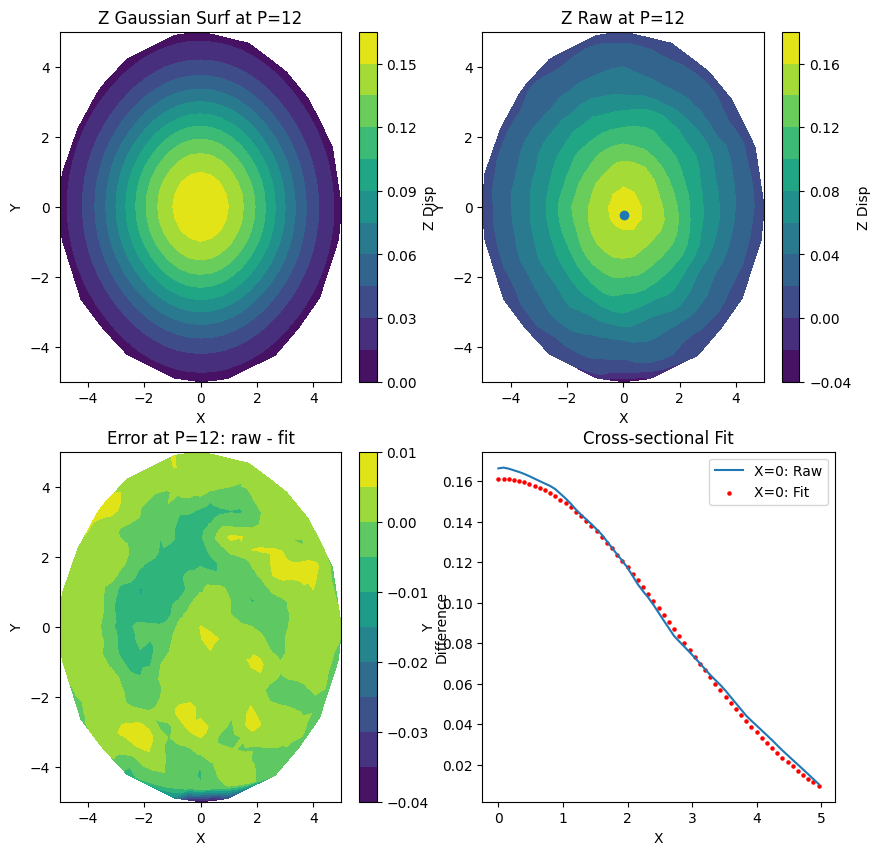

Centroids: X(2.156159702567941), Y(-1.3923056344429703)
sMAPE (new fit):   mean=2.62%, median=1.53%


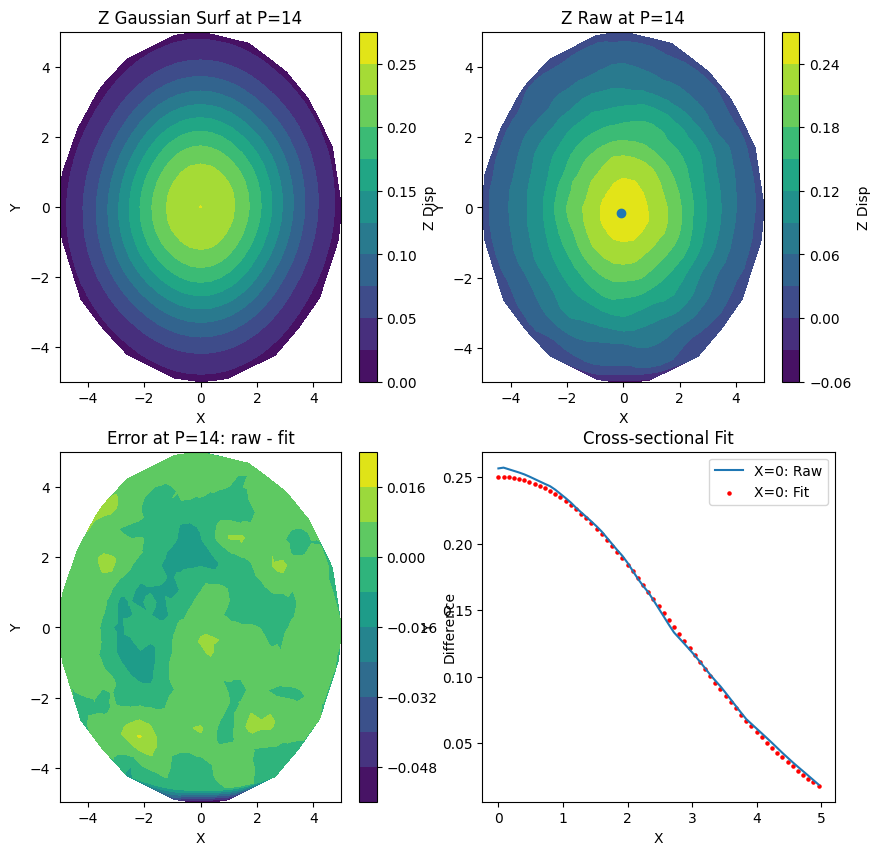

Centroids: X(2.2563060670124435), Y(-1.5523524239229465)
sMAPE (new fit):   mean=2.07%, median=1.55%


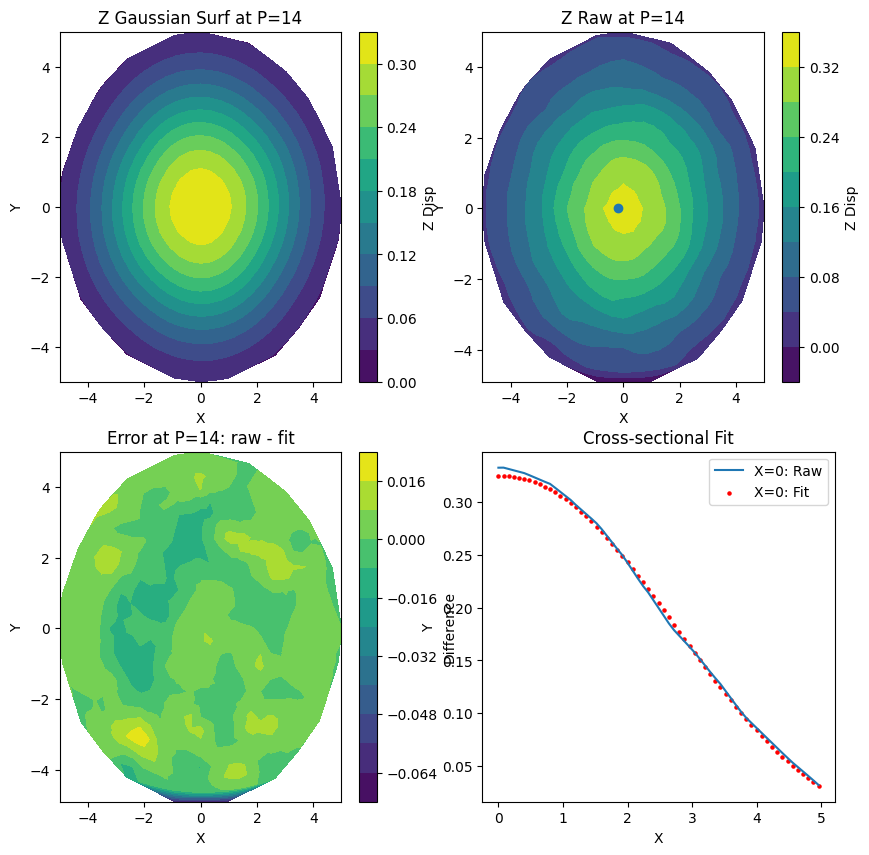

Centroids: X(2.351107672177567), Y(-1.649119640110047)
sMAPE (new fit):   mean=1.79%, median=1.20%


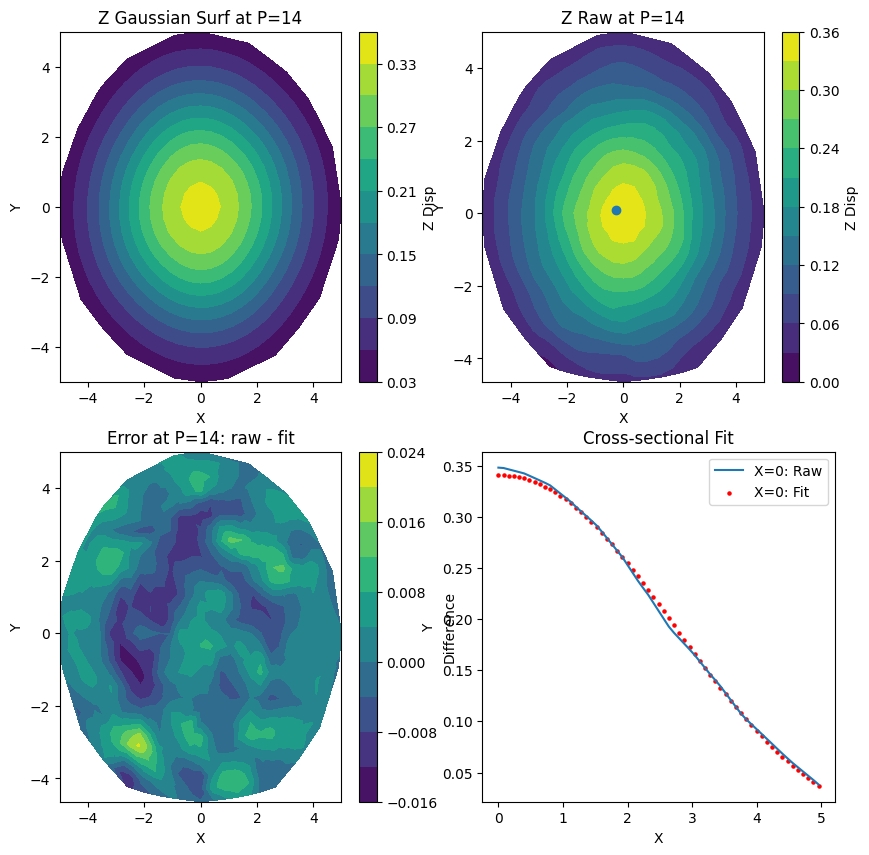

Centroids: X(2.3501400960786625), Y(-1.5147600621999242)
sMAPE (new fit):   mean=2.67%, median=1.47%


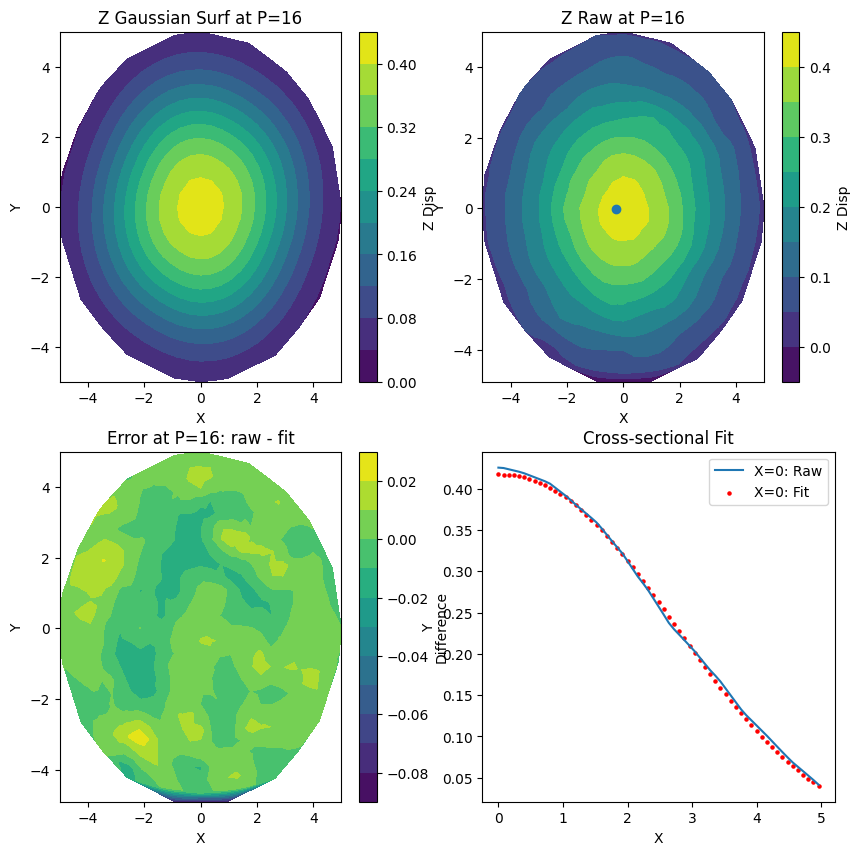

Centroids: X(2.5155698634347226), Y(-1.7424712713775286)
sMAPE (new fit):   mean=1.60%, median=1.06%


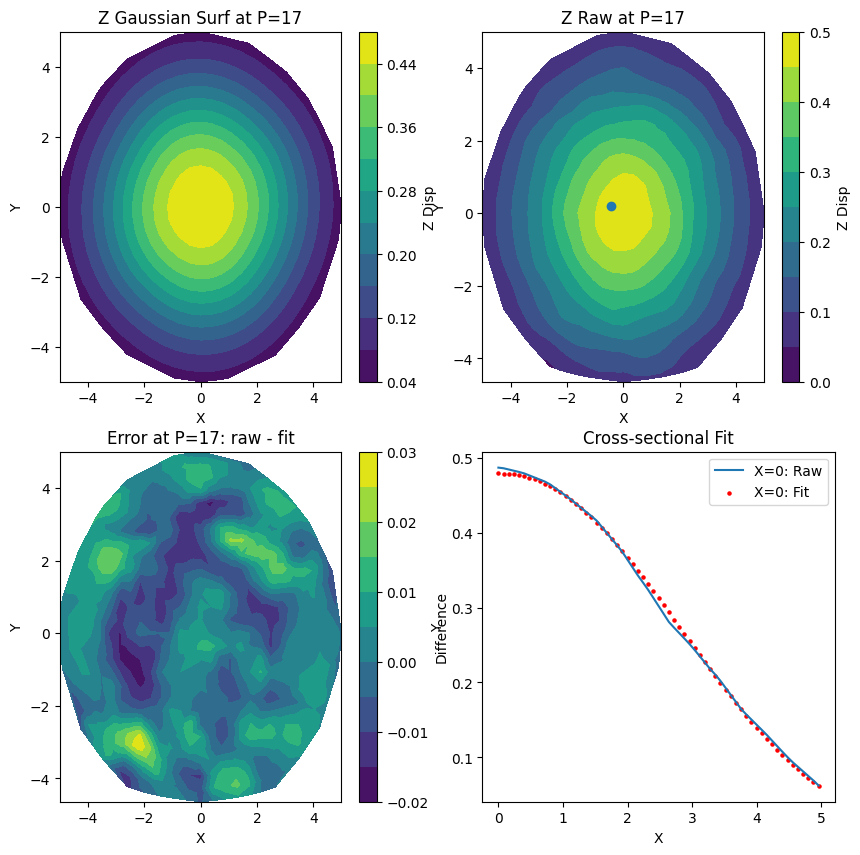

Centroids: X(2.4991894011476132), Y(-1.7264125437007893)
sMAPE (new fit):   mean=1.96%, median=1.38%


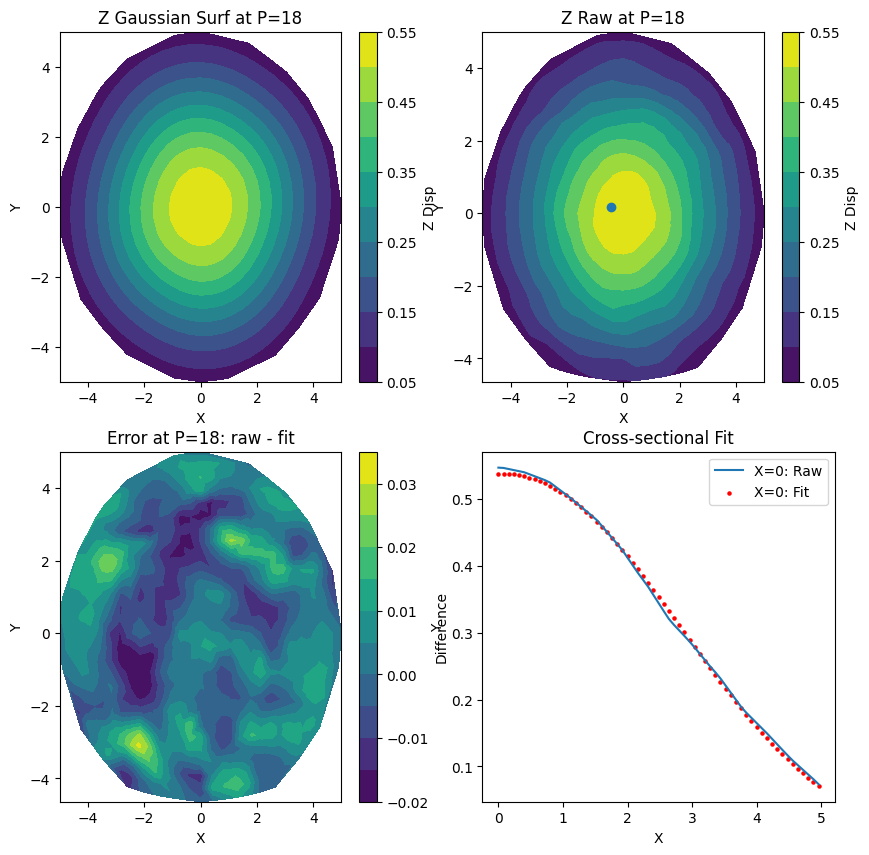

Centroids: X(2.493496515284167), Y(-1.8704703980316262)
sMAPE (new fit):   mean=1.85%, median=1.18%


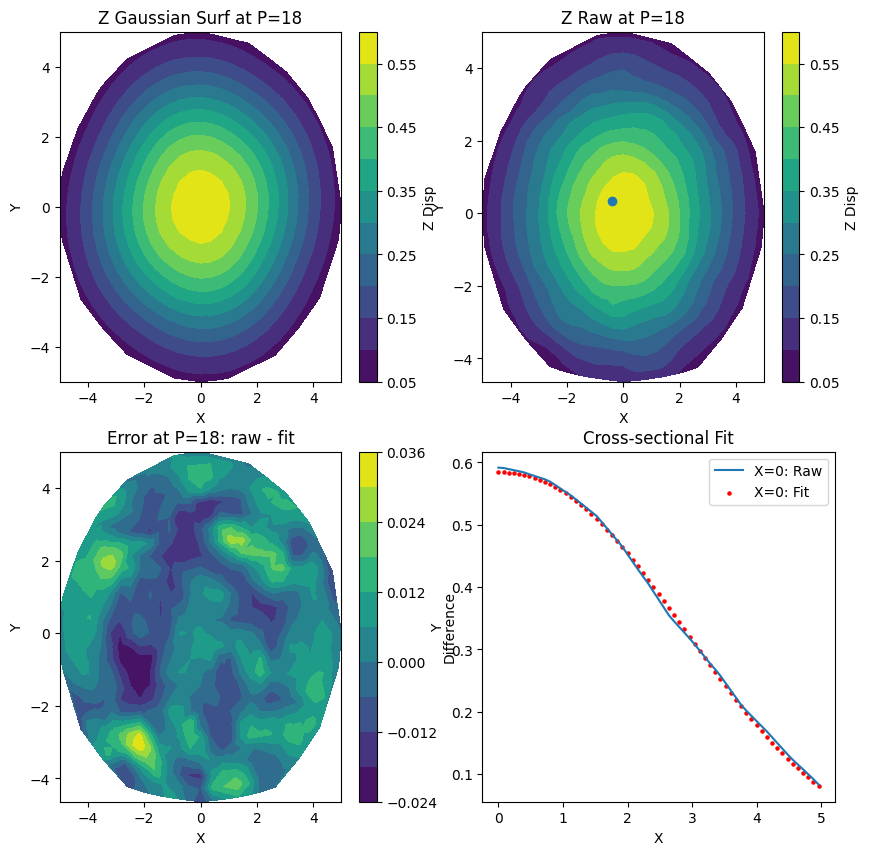

Centroids: X(2.6526790474414206), Y(-1.9258052237056387)
sMAPE (new fit):   mean=1.53%, median=0.92%


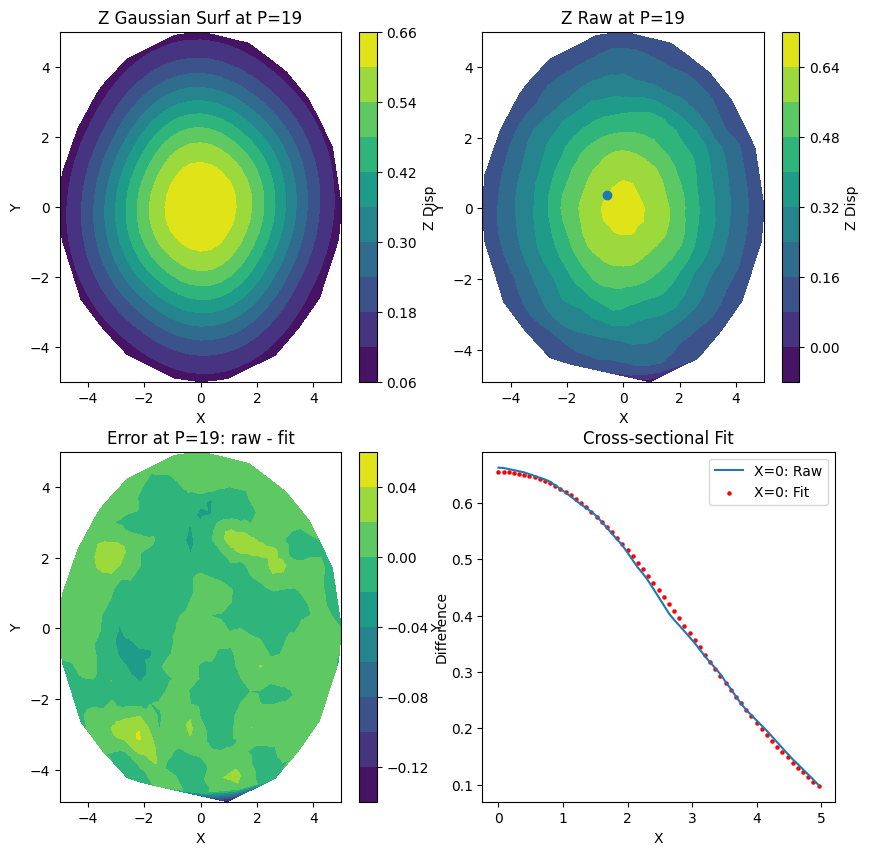

D1: Completed


In [34]:
import matplotlib.tri as tri
from scipy.optimize import curve_fit
from scipy.interpolate import griddata

radius_def = 5
mesh = meshio.read('/content/drive/My Drive/Rigid_body_removal/Mesh_Adjustment/FG7515T05_final_T4.inp')
top_node_inds = mesh.point_sets['TOP_SURF']
top_node_points = mesh.points[top_node_inds]
radius = np.sqrt(np.sum(top_node_points[:, :-1] ** 2, axis=1)) < (radius_def + 1e-8)
node_inds_3D = top_node_inds[radius]
top_node_points_3D = mesh.points[node_inds_3D][:, :-1]
mesh = meshio.read('/content/drive/My Drive/Rigid_body_removal/Mesh_Adjustment/Axisy_ver.inp')
top_node_inds = np.where(mesh.points[:, 1] == 4)[0]
top_node_points = mesh.points[top_node_inds]
radius = top_node_points[:, 0] < (radius_def + 1e-8)
node_inds = top_node_inds[radius]
top_node_points = mesh.points[node_inds]
top_node_points[:, -1] = 0
root = 'HT_250818'
creep_removed = False
warning_error = []

def rot_gauss(xy, A, x0, y0, sx, sy, theta, p, offset):
    xv, yv = xy
    ct, st = np.cos(theta), np.sin(theta)
    xp = ct*(xv-x0) + st*(yv-y0)
    yp = -st*(xv-x0) + ct*(yv-y0)
    core = (np.abs(xp/sx)**p + np.abs(yp/sy)**p)
    return offset + A * np.exp(-0.5 * core)

for d in range(len(select_dimples)):
  select_dimple = select_dimples[d]
  print(f"#################     DIMPLE {select_dimple}      ################# ")
  ggd_folder = "%s/%s/GGDrot_fit" % (save_path, select_dimple)
  X_corr_dim = np.load("%s/X_corr_dim%s.npy" % (save_path, select_dimple))
  # X_corr_dim = np.load("%s/X_corr_all.npy" % (save_path))
  p_aligned = p_aligned_full[d]
  time_aligned = (time_aligned_full[d] - time_aligned_full[d][0]) / 1e3
  aligned_actual = actual_aligned_full[d]
  reduced_t = time_aligned[inds_mod]
  reduced_temp = temp_aligned[inds_mod]
  reduced_p = p_aligned[inds_mod]
  num_frames = X_corr_dim.shape[0]
  os.makedirs(ggd_folder, exist_ok=True)
  if os.path.exists("%s/%s/Gaussian_fit_%s%s" % (save_path, select_dimple, select_dimple, ending)):
    for filename in os.listdir("%s/%s/Gaussian_fit_%s%s" % (save_path, select_dimple, select_dimple, ending)):
      if filename.endswith(".png"):
        os.remove("%s/%s/Gaussian_fit_%s%s/%s" % (save_path, select_dimple, select_dimple, ending, filename))
  os.makedirs("%s/%s/Gaussian_fit_%s%s" % (save_path, select_dimple, select_dimple, ending), exist_ok=True)
  p_aligned_mpa = p_aligned
  poi = poi_all[d]
  z_raw_full, z_fit_full, csv_val = [[] for i in range(3)]
  params = fit_params_final[d]
  cent = params[1:3]
  corrected_points = X_corr_dim[-1]
  dist = np.argmin(np.abs(corrected_points[:, 0] - cent[0]) + np.abs(corrected_points[:, 1] - cent[1]))
  cent_approx = [corrected_points[dist, 0], corrected_points[dist, 1]]
  params_fit_arr = np.zeros((len(poi), len(params)))
  for i in range(len(poi)):
    ind = poi[i]
    ind_align = poi[i]
    corrected_points = X_corr_dim[ind_align]
    x = corrected_points[:, 0]
    y = corrected_points[:, 1]
    z_data = -corrected_points[:, 2]
    xy_data_for_fit = np.vstack((x, y))
    params = fit_params_final[d]
    cent = params[1:3]
    sx0 = sy0 = max(np.ptp(x), np.ptp(y)) / 4.0
    # Define initial guesses and bounds based on the raw data
    p0 = [np.max(z_data), cent[0], cent[1], sx0, sy0, 0.0, 2, np.min(z_data)]
    lower = [0, cent[0] - 1, cent[1] - 1, 1e-3, 1e-3, -np.pi/2, 2, -np.inf]
    upper = [np.max(z_data) * 1.5, cent[0] + 1, cent[1] + 1, np.ptp(x)*2, np.ptp(y)*2, np.pi/2, 3, np.inf]
    # Perform the curve fitting
    try:
      params_fit, _ = curve_fit(rot_gauss, xy_data_for_fit, z_data,
                                p0=p0, bounds=(lower, upper))
      A, x0_0, y0_0, sx, sy, theta, p, offset = params_fit
      dist = np.abs(x - x0_0) + np.abs(y - y0_0)
      np.save("%s/GGD_%s_%i.npy" % (ggd_folder, select_dimple, ind_align), np.array(params_fit))
    except RuntimeError:
      warning_error.append(f"Warning {select_dimple}: GGD fit failed for frame {ind_align}. Try different frame.")
    params_fit[1:3] = 0
    z_fit = rot_gauss(np.vstack((top_node_points[:,0], top_node_points[:,1])), *params_fit)
    params_fit_arr[i] = params_fit
    z_fit_3D = rot_gauss(np.vstack((top_node_points_3D[:,0], top_node_points_3D[:,1])), *params_fit)
    z_raw = griddata(corrected_points[:, :-1] - [x0_0, y0_0], z_data, top_node_points, method='linear')
    z_raw_3D = griddata(corrected_points[:, :-1] - [x0_0, y0_0], z_data, top_node_points_3D, method='linear')
    raw_inds = np.where(~np.isnan(z_raw))[0]
    if len(raw_inds) > 0:
      z_raw = z_raw[raw_inds]
    raw_inds_3D = np.where(~np.isnan(z_raw_3D))[0]
    if len(raw_inds_3D) > 0:
      z_raw_3D = z_raw_3D[raw_inds_3D]
    max_zdisp = np.argmax(z_raw)
    z_raw_full.append(z_raw)
    # Per-point sMAPE fields (useful to plot error maps)
    if len(raw_inds) > 0:
      smape_fit_field = 2.0 * np.abs(z_raw - z_fit[raw_inds]) / (np.abs(z_raw) + np.abs(z_fit[raw_inds]) + 1e-12)
      valid = np.isfinite(z_raw) & np.isfinite(z_fit[raw_inds])
    else:
      smape_fit_field = 2.0 * np.abs(z_raw - z_fit) / (np.abs(z_raw) + np.abs(z_fit) + 1e-12)
      valid = np.isfinite(z_raw) & np.isfinite(z_fit)
    # Aggregate scores (0–2). Multiply by 100 for %
    smape_fit_mean   = np.nanmean(smape_fit_field[valid])   * 100.0
    smape_fit_median = np.nanmedian(smape_fit_field[valid]) * 100.0
    print(f"Centroids: X({x0_0}), Y({y0_0})")
    print(f"sMAPE (new fit):   mean={smape_fit_mean:.2f}%, median={smape_fit_median:.2f}%")
    csv_val.append([reduced_p[i], z_fit[0], z_raw[0], ind_align])
    z_fit_full.append(z_fit)
    plot_vals = np.column_stack((top_node_points_3D[:,0], top_node_points_3D[:,1], z_fit_3D))
    triang_q = tri.Triangulation(plot_vals[:, 0], plot_vals[:, 1])
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    contour_plot = axes[0][0].tricontourf(triang_q, plot_vals[:, 2], levels=10, cmap="viridis")
    fig.colorbar(contour_plot, ax=axes[0][0], label='%s Disp' % 'Z')
    axes[0][0].set_xlabel('X')
    axes[0][0].set_ylabel('Y')
    axes[0][0].set_title('Z Gaussian Surf at P=%i' % int(reduced_p[i]))
    if len(raw_inds) > 0:
      triang_q = tri.Triangulation(plot_vals[raw_inds_3D, 0], plot_vals[raw_inds_3D, 1])
    contour_plot2 = axes[0][1].tricontourf(triang_q, z_raw_3D, levels=10, cmap="viridis")
    fig.colorbar(contour_plot2, ax=axes[0][1], label='%s Disp' % 'Z')
    axes[0][1].set_xlabel('X')
    axes[0][1].set_ylabel('Y')
    axes[0][1].set_title('Z Raw at P=%i' % int(reduced_p[i]))
    axes[0][1].scatter(cent_approx[0] - x0_0, cent_approx[1] - y0_0)
    if len(raw_inds) > 0:
      # axes[0][1].scatter(top_node_points[raw_inds, 0][max_zdisp], top_node_points[raw_inds, 1][max_zdisp])
      contour_plot3 = axes[1][0].tricontourf(triang_q, z_raw_3D - plot_vals[raw_inds_3D, 2], levels=10, cmap="viridis")
    else:
      # axes[0][1].scatter(top_node_points[max_zdisp, 0], top_node_points[max_zdisp, 1])
      contour_plot3 = axes[1][0].tricontourf(triang_q, z_raw_3D - plot_vals[:, 2], levels=10, cmap="viridis")
    fig.colorbar(contour_plot3, ax=axes[1][0], label='Difference')
    axes[1][0].set_xlabel('X')
    axes[1][0].set_ylabel('Y')
    axes[1][0].set_title('Error at P=%i: raw - fit' % int(reduced_p[i]))
    x_val = np.linspace(-5, 5, 21)
    order = np.argsort(top_node_points[:,0])
    axes[1][1].plot(top_node_points[:,0][order], z_raw[order], label="X=0: Raw")
    axes[1][1].scatter(top_node_points[:,0], z_fit, label="X=0: Fit", c='r', s=5)
    axes[1][1].legend()
    axes[1][1].set_xlabel('X')
    axes[1][1].set_ylabel('Y')
    axes[1][1].set_title('Cross-sectional Fit')
    plt.savefig("%s/%s/Gaussian_fit_%s%s/Ind%i_ContourComp.png" % (save_path, select_dimple, select_dimple, ending, ind_align), dpi=150)
    plt.show()

  # CSV Val
  np.savetxt("%s/%s/Gaussian_fit_%s%s/%s_zdisp_comp.csv" % (save_path, select_dimple, select_dimple, ending, select_dimple), np.array(csv_val), delimiter=",")
  np.save("%s/%s/Gaussian_fit_%s%s/Gaussian_param.npy" % (save_path, select_dimple, select_dimple, ending), np.array(params_fit_arr))
  np.save("%s/%s/Gaussian_fit_%s%s/pressure_select.npy" % (save_path, select_dimple, select_dimple, ending), reduced_p)
  np.save("%s/%s/Gaussian_fit_%s%s/time_select.npy" % (save_path, select_dimple, select_dimple, ending), reduced_t)
  np.save("%s/%s/Gaussian_fit_%s%s/temp_select.npy" % (save_path, select_dimple, select_dimple, ending), reduced_temp)
  np.save("%s/%s/Gaussian_fit_%s%s/inds_mod.npy" % (save_path, select_dimple, select_dimple, ending), np.array(poi))
  np.save("%s/%s/Gaussian_fit_%s%s/raw_disp.npy" % (save_path, select_dimple, select_dimple, ending), np.array(z_raw_full))
  print(f"{select_dimple}: Completed")

for w in warning_error:
  print(w)

# End
